# RL 입력-편집 에이전트 (메인 모델 학습 없이, 이미 학습된 체크포인트만 사용)

메인 T5Gemma2 분류기는 **이미 다른 세션에서 학습 완료**되어 `model/` 체크포인트로 저장돼 있다고 가정합니다. 이 노트북은 그 체크포인트를 그대로 불러와서 **탐색 4클래스(read/grep/list/glob) RL 입력-편집 정책망만** 학습합니다.

**실행 전 체크리스트**
- Settings → Accelerator: **GPU**
- Settings → Internet: **Off여도 됨** (모델을 로컬 데이터셋에서 불러오므로 HuggingFace 다운로드가 필요 없습니다. 단, pip install엔 인터넷 필요)
- 학습된 `model/` 체크포인트를 담은 Kaggle Dataset을 **Add Input**으로 추가해두세요
- 원본 대회 데이터(`dacon111`, train.jsonl/train_labels.csv)도 Add Input으로 추가돼 있어야 합니다 (val 샘플 복원 및 confusion 판정에 필요)


## 0. 패키지 설치
(bitsandbytes는 메인 학습 전용이라 여기선 필요 없어서 뺐습니다)

In [1]:
!pip install -q "transformers>=4.50.0" sentencepiece accelerate "peft>=0.15.0" "torchao>=0.16.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.9 MB/s eta 0:00:00


## 1. `config.py` 작성

In [2]:
%%writefile config.py
"""
중앙 설정 파일.

내일 데이터를 받으면 여기서 컬럼명/모델명/직렬화 옵션만 바꾸면 됩니다.
대부분의 "데이터 의존적" 값은 PLACEHOLDER 주석으로 표시해 두었습니다.
"""
from dataclasses import dataclass, field
from typing import List


# =============================================================================
# 1) 모델 선택 — 여기 한 줄만 바꾸면 모델 교체됨
# =============================================================================
# ⚠️ 대회 평가서버 transformers==4.46.3 에서 ModernBERT/Qwen3는 "NOT AVAILABLE"(업그레이드 필요).
# EDA 결과: current_prompt 64% 한국어(ko) → 다국어/한국어 모델 필수.
#
# 기본(경량·서버호환·다국어) -> "microsoft/mdeberta-v3-base"
# 대안                       -> "FacebookAI/xlm-roberta-base"
# 업그레이드(한국어+코드 최강) -> "Qwen/Qwen2.5-1.5B" (Qwen2 arch, 4.46.3 OK, LoRA 권장)
#
# >>> 최종 결정: T5Gemma2 인코더로 교체 <<<
# GPU 여유가 없으므로 여러 백본/옵션을 스윕하지 않고 아래 하나로 고정.
# 이전에 실험 노트북에서 검증된 안정화 조합을 그대로 재사용:
#   - bf16 (fp16은 NaN 발생 이력 있음)
#   - eager attention 강제 (sdpa 오류 회피)
#   - vision_tower/multi_modal_projector 제거 (텍스트 인코더만 사용)
#   - LoRA lora_dropout=0.0 (CheckpointError 회피)
# train.py 가 MODEL_NAME에 "t5gemma"가 들어있으면 자동으로 전용 로딩 경로
# (T5GemmaEncoderClassifier: 인코더만 추출 + LoRA + attention pooling)를 탄다.
MODEL_NAME = "google/t5gemma-2-270m-270m"

# 검증된 노트북과 동일하게 256 유지 (512보다 메모리 절약, GPU 여유 없음 감안).
MAX_LENGTH = 256


# =============================================================================
# 2) 데이터 스키마 — 내일 실제 컬럼명으로 교체 (PLACEHOLDER)
# =============================================================================
@dataclass
class Columns:
    id: str = "id"                       # 샘플 식별자
    label: str = "action"                # 정답 클래스 (train_labels.csv 의 'action')
    current_prompt: str = "current_prompt"
    history: str = "history"             # list[dict]: user{role,content} / assistant_action{role,name,args,result_summary}
    session_meta: str = "session_meta"   # nested dict (user_tier, language_pref, workspace{...}, ...)


COLS = Columns()

# 제출 파일 컬럼명 (sample_submission.csv 와 일치)
SUBMISSION_ID_COL = "id"
SUBMISSION_PRED_COL = "action"

# 14개 클래스 (고정 순서). 대소문자까지 정확히 일치해야 함.
CLASS_NAMES: List[str] = [
    "read_file", "grep_search", "list_directory", "glob_pattern",
    "edit_file", "write_file", "apply_patch",
    "run_bash", "run_tests", "lint_or_typecheck",
    "ask_user", "plan_task", "web_search", "respond_only",
]

# 계층 분류용 coarse 그룹 (14 -> 4). 순서 = coarse id.
COARSE_GROUPS = [
    ("inspect",  ["read_file", "grep_search", "list_directory", "glob_pattern"]),
    ("modify",   ["edit_file", "write_file", "apply_patch"]),
    ("execute",  ["run_bash", "run_tests", "lint_or_typecheck"]),
    ("converse", ["ask_user", "plan_task", "web_search", "respond_only"]),
]


# =============================================================================
# 3) 직렬화 마커 — current_prompt + history + meta 를 한 문자열로
# =============================================================================
@dataclass
class SerializeCfg:
    meta_marker: str = "[META]"
    history_marker: str = "[HISTORY]"
    prompt_marker: str = "[PROMPT]"
    # history에서 최근 몇 스텝만 사용할지 (오래된 건 잘라냄). None이면 전부.
    max_history_steps: int = 12
    # --- 모듈식 입력 실험 플래그: GPU 여유 없어 스윕 대신 하나로 확정 ---
    # add_symbol_cues=True 로 결정: 이전 실험(T5Gemma 노트북)에서 F1이 가장 낮았던
    # 클래스가 read_file(0.51)/list_directory(0.46)/grep_search(0.59)/glob_pattern 등
    # "탐색 계열" 경계였음 -> 이 lexical 큐가 정확히 그 경계를 겨냥하고 비용도 거의 없음.
    add_symbol_cues: bool = True    # CUE에 판별 피처: has_path/symbol_query/dir_query/glob
                                    #   -> read↔grep↔list↔glob 경계용 (lexical, 짧은 입력에도 유효)
    add_open_files: bool = False    # 경로 노출은 과적합 위험 (comment 참조) -> off 유지
    add_langmix: bool = False       # toplang 플래그로 이미 충분 -> off 유지
    max_open_files: int = 8


SER = SerializeCfg()


# =============================================================================
# 4) 학습 하이퍼파라미터
# =============================================================================
@dataclass
class TrainCfg:
    output_dir: str = "model"            # 제출 zip의 model/ 디렉토리로 그대로 사용
    epochs: int = 4
    # GPU 여유 없음 -> 배치는 낮추고 accumulation으로 실질 배치 확보 (4 x 4 = 16, 검증된 조합)
    train_batch_size: int = 4
    grad_accum_steps: int = 4
    eval_batch_size: int = 16
    lr: float = 1e-4                     # T5Gemma+LoRA 검증값 (mdeberta 풀파인튜닝용 2e-5보다 큼)
    weight_decay: float = 0.01
    warmup_ratio: float = 0.06
    fp16: bool = False                   # T5Gemma는 fp16에서 NaN 이력 있음 -> bf16 사용
    bf16: bool = True                    # 실험 노트북에서 검증된 안정 설정
    optim: str = "adamw_bnb_8bit"        # bitsandbytes 8bit AdamW (옵티마이저 메모리 절약, 검증됨)
    seed: int = 42
    val_size: float = 0.1                # stratified hold-out 비율

    # 클래스 불균형 대응: "weighted_ce" | "focal" | "none"
    loss_type: str = "weighted_ce"
    focal_gamma: float = 2.0

    # 검증셋에서 클래스별 threshold를 Macro-F1 기준으로 최적화해 저장할지
    tune_thresholds: bool = True

    # --- T5Gemma2 인코더 전용: LoRA 설정 (여러 경우의 수 대신 하나로 확정) ---
    use_lora: bool = True                # LoRA 없이 270M 풀파인튜닝은 GPU 여유상 비권장
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.0            # 반드시 0.0! (>0 이면 CheckpointError, 노트북에서 확인됨)
    lora_target_modules: List[str] = field(default_factory=lambda: ["q_proj", "v_proj"])


TRAIN = TrainCfg()


Writing config.py


## 2. `common.py` 작성

In [3]:
%%writefile common.py
"""
학습/추론이 공유하는 핵심 로직: 입력 직렬화 + 라벨 인코딩.

주의: 추론 코드(script.py)는 제출 zip 구조 안정성을 위해 *standalone*으로 만들었고,
serialize() 함수를 그대로 복사해 둡니다. 이 파일과 script.py의 serialize()는
반드시 동일하게 유지하세요 (KEEP IN SYNC). 동작은 model/serialize_config.json 으로
잠그기 때문에, 함수 시그니처만 같으면 결과는 항상 일치합니다.
"""
import json
import re
from typing import Any, Dict, List

# 탐색 클러스터 판별용 lexical 패턴 (KEEP IN SYNC with script.py)
_PATH_RE = re.compile(r"[\w./-]+\.(py|ts|js|tsx|jsx|java|go|rs|sql|ya?ml|json|md|toml|cfg|ini|sh|rb|php|cpp?|h|hpp)\b", re.I)
_SYM_RE = re.compile(r"어디|정의|찾아|찾을|참조|걸린|import|where|defined|declared|uses?|reference|grep|검색", re.I)
_DIR_RE = re.compile(r"목록|뭐\s*있|어떤\s*파일|리스트|디렉|폴더|구조|ls\b|list|안에\s*뭐|들어\s*?있", re.I)
_GLOB_RE = re.compile(r"\*\.|모든\s|전부|테스트\s*파일|\.\w+\s*파일|패턴|매칭|glob|all\s+\w+\s+files", re.I)


def _explore_cues(prompt: str) -> Dict[str, int]:
    p = prompt or ""
    return {
        "path": 1 if _PATH_RE.search(p) else 0,   # 명시 파일경로 -> read_file
        "sym":  1 if _SYM_RE.search(p) else 0,     # 심볼/개념 쿼리 -> grep_search
        "dir":  1 if _DIR_RE.search(p) else 0,     # 디렉토리 질의 -> list_directory
        "glob": 1 if _GLOB_RE.search(p) else 0,    # 패턴 -> glob_pattern
    }


# ---------------------------------------------------------------------------
# 입력 직렬화: current_prompt + history + session_meta -> 단일 문자열
# ---------------------------------------------------------------------------
def _fmt_args(args: Any) -> str:
    if not isinstance(args, dict) or not args:
        return ""
    return ",".join(f"{k}={v}" for k, v in args.items())


def get_history_pairs(history: Any, max_steps: int) -> List[str]:
    """_stringify_history 내부 로직을 그대로 쓰되, 최종 문자열이 아니라 시간순
    (오래된 -> 최신) pair 문자열 리스트를 반환한다. RL 입력-편집 모듈이 특정
    위치(step)의 pair 하나만 골라 다른 샘플의 것으로 바꿔치기하려면 이렇게
    쪼개진 리스트가 필요해서 분리했다. serialize() 결과는 이 함수를 거쳐도
    100% 동일하게 유지된다 (아래 _stringify_history 참조)."""
    if history is None:
        return []
    if isinstance(history, str):
        s = history.strip()
        return [s] if s else []
    if not isinstance(history, list):
        return [str(history)]

    def is_action(s):
        return isinstance(s, dict) and (s.get("role") == "assistant_action" or s.get("name"))

    # (user 요청 -> 그 결과 action) 을 한 덩어리로 묶음 = prompt->action 시연
    pairs: List[str] = []
    i, n = 0, len(history)
    while i < n:
        t = history[i]
        if not isinstance(t, dict):
            i += 1; continue
        if is_action(t):                      # user 없는 action
            a = t
            pairs.append(f"({a.get('name','')}({_fmt_args(a.get('args'))}): "
                         f"{(a.get('result_summary') or '').strip()})")
            i += 1
        else:                                 # user turn
            content = (t.get("content") or t.get("text") or "").strip()
            if i + 1 < n and is_action(history[i + 1]):   # 다음 action 과 묶기
                a = history[i + 1]
                pairs.append(f"(user: {content} -> {a.get('name','')}"
                             f"({_fmt_args(a.get('args'))}): {(a.get('result_summary') or '').strip()})")
                i += 2
            else:
                pairs.append(f"(user: {content})")
                i += 1

    if max_steps is not None and len(pairs) > max_steps:
        pairs = pairs[-max_steps:]           # 최근 쌍 우선 보존
    return pairs   # 시간순(오래된 -> 최신). reverse는 호출부에서.


def _stringify_history(history: Any, max_steps: int) -> str:
    """실제 포맷: user{role,content} / assistant_action{role,name,args,result_summary}."""
    pairs = get_history_pairs(history, max_steps)
    return " ".join(reversed(pairs))         # 최근->과거 (truncation 시 오래된 쌍부터)


def _stringify_meta(meta: Any, add_open_files: bool = False,
                    add_langmix: bool = False, max_open: int = 8) -> str:
    """nested session_meta 평탄화. 블록별 토글로 open_files/langmix 개별 추가."""
    if meta is None:
        return ""
    if not isinstance(meta, dict):
        return str(meta)
    ws = meta.get("workspace") or {}
    open_files = ws.get("open_files") or []
    lang_mix = ws.get("language_mix") or {}
    top_lang = max(lang_mix, key=lang_mix.get) if isinstance(lang_mix, dict) and lang_mix else "na"
    # 식별자(파일경로) 대신 강건한 플래그만 (경로는 과적합)
    has_test = 1 if any("test" in str(f).lower() for f in open_files) else 0
    has_cfg = 1 if any(str(f).endswith((".yml", ".yaml", ".toml", ".json", ".cfg", ".ini"))
                       for f in open_files) else 0
    parts = [
        f"tier={meta.get('user_tier')}",
        f"lang={meta.get('language_pref')}",
        f"turn={meta.get('turn_index')}",
        f"budget={meta.get('budget_tokens_remaining')}",
        f"ci={ws.get('last_ci_status')}",
        f"dirty={ws.get('git_dirty')}",
        f"loc={ws.get('loc')}",
        f"toplang={top_lang}",
        f"nopen={len(open_files)}",
        f"hastest={has_test}",
        f"hascfg={has_cfg}",
    ]
    if add_open_files:
        # 빈 상태(cold-start)도 명시 마커(none)로 -> 학습/추론 표현 일관 (absence 금지)
        val = ",".join(str(f) for f in open_files[:max_open]) if open_files else "none"
        parts.append(f"open_files={val}")
    if add_langmix and isinstance(lang_mix, dict) and lang_mix:
        parts.append("langmix=" + ",".join(f"{k}:{v}" for k, v in lang_mix.items()))
    return " ".join(parts)


def serialize(current_prompt: Any, history: Any, session_meta: Any, cfg: Dict) -> str:
    """
    cfg 예시 (model/serialize_config.json 으로 저장/로드):
      {"meta_marker":"[META]","history_marker":"[HISTORY]",
       "prompt_marker":"[PROMPT]","max_history_steps":12}
    """
    meta_s = _stringify_meta(session_meta, cfg.get("add_open_files", False),
                             cfg.get("add_langmix", False), cfg.get("max_open_files", 8))
    hist_s = _stringify_history(history, cfg.get("max_history_steps"))
    prompt_s = "" if current_prompt is None else str(current_prompt).strip()

    # 강건한 신호만 (이진 플래그). plen(정확한 길이)은 과적합이라 제거.
    q = 1 if prompt_s.endswith("?") else 0
    short = 1 if len(prompt_s) < 25 else 0
    cue = f"[CUE] q={q} short={short}"
    # 판별 피처(add_symbol_cues): 탐색 클러스터 경계용 lexical 신호
    if cfg.get("add_symbol_cues", False):
        c = _explore_cues(prompt_s)
        cue += f" path={c['path']} sym={c['sym']} dir={c['dir']} glob={c['glob']}"

    # 순서: 현재발화 -> cue -> 최근history -> meta.
    parts = [f"{cfg['prompt_marker']} {prompt_s}", cue]
    if hist_s:
        parts.append(f"{cfg['history_marker']} {hist_s}")
    if meta_s:
        parts.append(f"{cfg['meta_marker']} {meta_s}")
    return " ".join(parts)


def serialize_from_pairs(current_prompt: Any, pairs: List[str], session_meta: Any, cfg: Dict) -> str:
    """RL 입력-편집 모듈 전용. history를 다시 파싱하지 않고, 이미 만들어진(일부
    step이 다른 샘플 것으로 바꿔치기된) pairs 리스트를 그대로 조립해 직렬화한다.
    serialize()와 완전히 동일한 포맷/순서를 유지한다 (KEEP IN SYNC with serialize())."""
    meta_s = _stringify_meta(session_meta, cfg.get("add_open_files", False),
                             cfg.get("add_langmix", False), cfg.get("max_open_files", 8))
    hist_s = " ".join(reversed(pairs))
    prompt_s = "" if current_prompt is None else str(current_prompt).strip()

    q = 1 if prompt_s.endswith("?") else 0
    short = 1 if len(prompt_s) < 25 else 0
    cue = f"[CUE] q={q} short={short}"
    if cfg.get("add_symbol_cues", False):
        c = _explore_cues(prompt_s)
        cue += f" path={c['path']} sym={c['sym']} dir={c['dir']} glob={c['glob']}"

    parts = [f"{cfg['prompt_marker']} {prompt_s}", cue]
    if hist_s:
        parts.append(f"{cfg['history_marker']} {hist_s}")
    if meta_s:
        parts.append(f"{cfg['meta_marker']} {meta_s}")
    return " ".join(parts)


def serialize_config_from(SER) -> Dict:
    return {
        "meta_marker": SER.meta_marker,
        "history_marker": SER.history_marker,
        "prompt_marker": SER.prompt_marker,
        "max_history_steps": SER.max_history_steps,
        "add_symbol_cues": SER.add_symbol_cues,
        "add_open_files": SER.add_open_files,
        "add_langmix": SER.add_langmix,
        "max_open_files": SER.max_open_files,
    }


# ---------------------------------------------------------------------------
# 라벨 인코딩
# ---------------------------------------------------------------------------
def build_label_maps(labels: List[str], class_names: List[str] = None):
    """label2id, id2label 생성. class_names 주어지면 그 순서 고정, 아니면 정렬해서 사용."""
    if class_names:
        classes = list(class_names)
    else:
        classes = sorted(set(map(str, labels)))
    label2id = {c: i for i, c in enumerate(classes)}
    id2label = {i: c for c, i in label2id.items()}
    return label2id, id2label


Writing common.py


## 3. `train.py` 작성 (2셀 분할)

이 노트북에서 `train.py`는 **실행하지 않습니다** — `T5GemmaEncoderClassifier`, `_force_eager_attention` 등 클래스/함수만 재사용하려고 파일로 만들어두는 겁니다.

In [4]:
%%writefile train.py
"""
학습 스크립트 (로컬 GPU에서 실행 -> model/ 산출 -> 제출 zip에 그대로 포함).

실행:
  python train.py --data ./train.csv

산출물 (model/):
  - config.json, model.safetensors, tokenizer 파일들  (HF 표준)
  - label_maps.json        : label2id / id2label
  - serialize_config.json  : 직렬화 마커 (추론과 동일 보장)
  - thresholds.json        : (옵션) 클래스별 Macro-F1 최적 임계값
"""
import argparse
import json
import os
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers.utils import ModelOutput
from dataclasses import dataclass
from typing import Optional

import config as C
from common import serialize, serialize_config_from, build_label_maps


@dataclass
class HierOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    coarse_logits: torch.FloatTensor = None


class HierClassifier(nn.Module):
    """계층(멀티태스크) 분류: 인코더 공유 + fine(14) 헤드 + coarse(4) 보조 헤드.
    coarse는 학습 시 regularizer, 추론은 fine 헤드만 사용."""
    def __init__(self, backbone_name, num_labels, n_coarse, id2label, label2id, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        h = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fine_head = nn.Linear(h, num_labels)
        self.coarse_head = nn.Linear(h, n_coarse)
        self.num_labels = num_labels
        self.config = self.backbone.config
        self.config.num_labels = num_labels
        self.config.id2label = id2label
        self.config.label2id = label2id

    def _pool(self, H, mask):
        m = mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-6)   # masked mean

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kw):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None and getattr(self.config, "type_vocab_size", 0):
            kwargs["token_type_ids"] = token_type_ids
        H = self.backbone(**kwargs).last_hidden_state
        pooled = self.dropout(self._pool(H, attention_mask))
        fine = self.fine_head(pooled)
        if self.training:
            return HierOutput(logits=fine, coarse_logits=self.coarse_head(pooled))
        return SequenceClassifierOutput(logits=fine)


# ---------------------------------------------------------------------------
# T5Gemma2 인코더 전용 분류기 (config.MODEL_NAME 에 "t5gemma" 포함 시 자동 사용)
#
# 아래 안정화 조치는 전부 사전 실험 노트북에서 시행착오로 검증된 것들이며,
# T5Gemma는 이 조치들이 빠지면 학습이 잘 깨지므로 절대 임의로 빼지 말 것:
#   1) dtype=bfloat16 (fp16은 오버플로우로 NaN 발생 이력)
#   2) 전체 서브모듈 config._attn_implementation="eager" 로 고정 (sdpa 오류 회피)
#   3) vision_tower / multi_modal_projector 제거 (텍스트 인코더만 필요, 메모리 절약)
#   4) LoRA lora_dropout=0.0 고정 (>0이면 gradient checkpointing류 CheckpointError 발생 이력)
#   5) gradient checkpointing 사용 안 함 (노트북에서 인자 전달 시 에러 -> 제거하고 안정화됨)
# ---------------------------------------------------------------------------
def _force_eager_attention(root: nn.Module):
    """모든 하위 config 객체(text_config/vision_config 포함)의 attention 구현을
    eager로 강제. T5Gemma2는 forward 시점에 config를 다시 참조하므로 로드 후
    패치해도 적용된다 (노트북 실험에서 확인됨)."""
    seen = set()

    def _set(cfg):
        if cfg is None or id(cfg) in seen:
            return
        seen.add(id(cfg))
        try:
            cfg._attn_implementation = "eager"
        except Exception:
            pass
        for attr in ("text_config", "vision_config"):
            if hasattr(cfg, attr):
                _set(getattr(cfg, attr))

    if hasattr(root, "config"):
        _set(root.config)
    for _, sub in root.named_modules():
        if hasattr(sub, "config"):
            _set(sub.config)


def _infer_hidden_size(encoder_module):
    """분류헤드(attn/classifier) 입력 차원을 구한다.

    config 속성 이름은 모델 계열마다 제각각이다 (hidden_size / d_model / n_embd /
    text_config 하위 등) — 실제로 T5Gemma2EncoderConfig에는 hidden_size가 없어서
    한 번 에러가 났었다. 앞으로 또 다른 모델로 바꿔도 같은 종류의 에러가 안 나도록,
    config 속성명을 추측하는 대신 '실제 임베딩 가중치의 shape'에서 직접 구한다.
    이 값은 항상 정확하고, 모델이 바뀌어도 깨지지 않는다.
    """
    if hasattr(encoder_module, "embed_tokens") and encoder_module.embed_tokens is not None:
        return encoder_module.embed_tokens.weight.shape[-1]
    if hasattr(encoder_module, "get_input_embeddings"):
        emb = encoder_module.get_input_embeddings()
        if emb is not None:
            return emb.weight.shape[-1]
    # 여기까지 왔으면 임베딩을 못 찾은 것 -> config 속성명 몇 가지만 최후 수단으로 시도
    cfg = getattr(encoder_module, "config", None)
    for name in ("hidden_size", "d_model", "model_dim", "n_embd", "embedding_size"):
        if cfg is not None and hasattr(cfg, name):
            return getattr(cfg, name)
        text_cfg = getattr(cfg, "text_config", None) if cfg is not None else None
        if text_cfg is not None and hasattr(text_cfg, name):
            return getattr(text_cfg, name)
    raise AttributeError(
        "인코더에서 hidden size를 찾을 수 없습니다. "
        "encoder_module.config 를 직접 출력해서 어떤 속성에 차원 정보가 있는지 확인하세요."
    )


class T5GemmaEncoderClassifier(nn.Module):
    """T5Gemma2 텍스트 인코더(비전 제거) + LoRA(옵션) + attention pooling 분류기.

    다른 커스텀 분류기(AttnPoolClassifier 등)와 인터페이스는 동일하지만, 백본
    로딩/안정화 절차가 T5Gemma2 전용으로 특수하기 때문에 별도 클래스로 분리했다.
    """

    def __init__(self, backbone_name, num_labels, id2label, label2id,
                 use_lora=True, lora_r=16, lora_alpha=32, lora_dropout=0.0,
                 lora_target_modules=("q_proj", "v_proj"), dropout=0.1):
        super().__init__()
        full = AutoModel.from_pretrained(backbone_name, dtype=torch.bfloat16)
        encoder = full.encoder  # T5Gemma2Encoder (텍스트+비전 포함된 원본에서 추출)

        # 텍스트 전용 사용 -> 비전 관련 서브모듈 제거 (파라미터/메모리 절약)
        if hasattr(encoder, "vision_tower"):
            del encoder.vision_tower
        if hasattr(encoder, "multi_modal_projector"):
            del encoder.multi_modal_projector
        del full
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

        _force_eager_attention(encoder)

        # LoRA로 감싸기 전, 원본 encoder 모듈에서 hidden size를 먼저 확정해둔다
        # (peft로 감싼 뒤에도 접근은 되지만, 감싸기 전이 가장 확실하고 단순함).
        h = _infer_hidden_size(encoder)

        self.uses_lora = use_lora
        if use_lora:
            from peft import LoraConfig, get_peft_model
            lora_cfg = LoraConfig(
                r=lora_r, lora_alpha=lora_alpha,
                target_modules=list(lora_target_modules),
                lora_dropout=lora_dropout,   # 반드시 0.0 유지 (docstring 참조)
                bias="none",
            )
            encoder = get_peft_model(encoder, lora_cfg)
            base_cfg = encoder.get_base_model().config
        else:
            base_cfg = encoder.config

        self.encoder = encoder
        self.attn = nn.Linear(h, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(h, num_labels)
        self.num_labels = num_labels
        # HF 호환용 config (id2label 등 저장/로드 편의). hidden_size 속성이 원래
        # 없던 config라도 우리가 구한 값을 박아넣어 이후 코드가 참조해도 안전하게.
        self.config = base_cfg
        try:
            self.config.hidden_size = h
        except Exception:
            pass
        self.config.num_labels = num_labels
        self.config.id2label = id2label
        self.config.label2id = label2id

    def get_base_encoder(self):
        return self.encoder.get_base_model() if self.uses_lora else self.encoder

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        H = out.last_hidden_state.float()          # bf16 -> fp32 (분류헤드/softmax 안정성)
        scores = self.attn(H).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (H * w).sum(dim=1)
        logits = self.classifier(self.dropout(pooled))
        return SequenceClassifierOutput(logits=logits)


# ---------------------------------------------------------------------------
# Attention Pooling 분류기 (--pool attn): [CLS] 대신 학습형 attention 가중합
# ---------------------------------------------------------------------------
class AttnPoolClassifier(nn.Module):
    """backbone hidden states 에 학습 query로 softmax attention -> 가중합 -> 분류.
    모델이 발화·직전 action 등 정보량 큰 토큰에 스스로 가중치를 주도록 유도."""
    def __init__(self, backbone_name, num_labels, id2label, label2id, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        h = self.backbone.config.hidden_size
        self.attn = nn.Linear(h, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(h, num_labels)
        self.num_labels = num_labels
        # HF 호환용 config (id2label 등 저장/로드 편의)
        self.config = self.backbone.config
        self.config.num_labels = num_labels
        self.config.id2label = id2label
        self.config.label2id = label2id

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kw):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None and getattr(self.config, "type_vocab_size", 0):
            kwargs["token_type_ids"] = token_type_ids
        out = self.backbone(**kwargs)
        H = out.last_hidden_state                         # (B,T,h)
        scores = self.attn(H).squeeze(-1)                 # (B,T)
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)    # (B,T,1)
        pooled = (H * w).sum(dim=1)                        # (B,h)
        logits = self.classifier(self.dropout(pooled))
        return SequenceClassifierOutput(logits=logits)


# ---------------------------------------------------------------------------
# 데이터 로딩 (PLACEHOLDER: 내일 실제 포맷에 맞게 조정)
# ---------------------------------------------------------------------------
def _maybe_json(x):
    """CSV 셀 안에 JSON 문자열로 들어온 history/meta를 파싱."""
    if isinstance(x, str):
        s = x.strip()
        if s and s[0] in "[{":
            try:
                return json.loads(s)
            except Exception:
                return x
    return x


def load_dataframe(path: str) -> pd.DataFrame:
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
    elif path.endswith(".jsonl"):
        df = pd.read_json(path, lines=True)
    elif path.endswith(".json"):
        df = pd.read_json(path)
    else:
        df = pd.read_csv(path)
    for col in (C.COLS.history, C.COLS.session_meta):
        if col in df.columns:
            df[col] = df[col].map(_maybe_json)
    return df


def to_text(df: pd.DataFrame, include_history: bool = True) -> list:
    ser_cfg = serialize_config_from(C.SER)
    out = []
    for _, r in df.iterrows():
        hist = r.get(C.COLS.history) if include_history else None  # prompt-중심 실험용
        out.append(
            serialize(
                r.get(C.COLS.current_prompt),
                hist,
                r.get(C.COLS.session_meta),
                ser_cfg,
            )
        )
    return out


# ---------------------------------------------------------------------------
# 클래스 불균형 대응 Trainer
# ---------------------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


@dataclass
class SupConOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    proj: torch.FloatTensor = None


class SupConClassifier(nn.Module):
    """인코더 공유 + 분류헤드 + projection헤드. SupCon으로 같은 클래스 표현을 뭉치게."""
    def __init__(self, backbone_name, num_labels, id2label, label2id, proj_dim=128, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        h = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(h, num_labels)
        self.proj = nn.Sequential(nn.Linear(h, h), nn.ReLU(), nn.Linear(h, proj_dim))
        self.num_labels = num_labels
        self.config = self.backbone.config
        self.config.num_labels = num_labels
        self.config.id2label = id2label
        self.config.label2id = label2id

    def _pool(self, H, mask):
        m = mask.unsqueeze(-1).float()
        return (H * m).sum(1) / m.sum(1).clamp(min=1e-6)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kw):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None and getattr(self.config, "type_vocab_size", 0):
            kwargs["token_type_ids"] = token_type_ids
        pooled = self._pool(self.backbone(**kwargs).last_hidden_state, attention_mask)
        logits = self.classifier(self.dropout(pooled))
        if self.training:
            z = nn.functional.normalize(self.proj(pooled), dim=1)
            return SupConOutput(logits=logits, proj=z)
        return SequenceClassifierOutput(logits=logits)


def supcon_loss(feats, labels, temp=0.1):
    """Supervised Contrastive: 같은 클래스 당기고 다른 클래스 밀어냄."""
    device = feats.device
    B = feats.shape[0]
    sim = (feats @ feats.T) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()   # 안정화
    self_mask = torch.eye(B, device=device)
    exp_sim = torch.exp(sim) * (1 - self_mask)
    log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-12)
    pos = (labels.unsqueeze(0) == labels.unsqueeze(1)).float() * (1 - self_mask)
    pos_cnt = pos.sum(1)
    loss = -(pos * log_prob).sum(1) / pos_cnt.clamp(min=1)
    loss = loss[pos_cnt > 0]
    return loss.mean() if loss.numel() > 0 else torch.tensor(0.0, device=device)


class FGM:
    """Fast Gradient Method — 워드 임베딩에 grad 방향 perturbation을 줘 적대학습."""
    def __init__(self, model, emb_name="word_embeddings", eps=1.0):
        self.model = model
        self.emb_name = emb_name
        self.eps = eps
        self.backup = {}

    def attack(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name and param.grad is not None:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    param.data.add_(self.eps * param.grad / norm)

    def restore(self):
        for name, param in self.model.named_parameters():
            if name in self.backup:
                param.data = self.backup[name]
        self.backup = {}


class AWP:
    """Adversarial Weight Perturbation — 가중치를 grad 방향으로 eps-ball 내 교란해 적대학습.
    FGM(입력 교란)보다 강함. 저신뢰 경계 일반화에 효과."""
    def __init__(self, model, adv_param="weight", adv_lr=1e-4, adv_eps=1e-2):
        self.model = model
        self.adv_param = adv_param
        self.adv_lr = adv_lr
        self.adv_eps = adv_eps
        self.backup = {}
        self.backup_eps = {}

    def perturb(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad and p.grad is not None and self.adv_param in n:
                if n not in self.backup:
                    self.backup[n] = p.data.clone()
                    eps = self.adv_eps * p.abs().detach()
                    self.backup_eps[n] = (self.backup[n] - eps, self.backup[n] + eps)
                norm_g = torch.norm(p.grad)
                norm_d = torch.norm(p.detach())
                if norm_g != 0 and not torch.isnan(norm_g):
                    r = self.adv_lr * p.grad / (norm_g + 1e-12) * (norm_d + 1e-12)
                    p.data.add_(r)
                    p.data = torch.min(torch.max(p.data, self.backup_eps[n][0]),
                                       self.backup_eps[n][1])

    def restore(self):
        for n, p in self.model.named_parameters():
            if n in self.backup:
                p.data = self.backup[n]
        self.backup = {}
        self.backup_eps = {}


class ImbalancedTrainer(Trainer):
    def __init__(self, *args, loss_type="weighted_ce", class_weights=None, focal_gamma=2.0,
                 use_fgm=False, fgm_eps=1.0, kd_alpha=0.0, kd_temp=2.0,
                 hier_lambda=0.0, fine2coarse=None, supcon_w=0.0, supcon_temp=0.1,
                 use_awp=False, awp_lr=1e-4, awp_eps=1e-2, awp_start_epoch=1,
                 label_smoothing=0.0, **kw):
        super().__init__(*args, **kw)
        self.loss_type = loss_type
        self.focal_gamma = focal_gamma
        self._cw = class_weights
        self.use_fgm = use_fgm
        self.fgm = FGM(self.model, eps=fgm_eps) if use_fgm else None
        self.use_awp = use_awp
        self.awp = AWP(self.model, adv_lr=awp_lr, adv_eps=awp_eps) if use_awp else None


Writing train.py


In [5]:
%%writefile -a train.py
        self.awp_start_epoch = awp_start_epoch
        self.label_smoothing = label_smoothing
        self.kd_alpha = kd_alpha      # 증류 가중치 (0=순수 CE)
        self.kd_temp = kd_temp        # temperature
        self.hier_lambda = hier_lambda            # 계층 coarse 보조손실 가중치
        self.fine2coarse = fine2coarse            # (14,) fine id -> coarse id
        self.supcon_w = supcon_w                  # SupCon 가중치
        self.supcon_temp = supcon_temp

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        # non-destructive: FGM이 같은 배치로 두 번 호출하므로 inputs를 변형하지 않음
        labels = inputs["labels"]
        teacher = inputs.get("teacher_logits")
        model_inputs = {k: v for k, v in inputs.items()
                        if k not in ("labels", "teacher_logits")}
        outputs = model(**model_inputs)
        logits = outputs.logits
        w = self._cw.to(logits.device) if self._cw is not None else None
        ls = self.label_smoothing
        if self.loss_type == "focal":
            ce = FocalLoss(self.focal_gamma, weight=w)(logits, labels)
        elif self.loss_type == "weighted_ce":
            ce = nn.functional.cross_entropy(logits, labels, weight=w, label_smoothing=ls)
        else:
            ce = nn.functional.cross_entropy(logits, labels, label_smoothing=ls)
        # Knowledge Distillation: KL(student ‖ teacher) at temperature T
        if self.kd_alpha > 0 and teacher is not None:
            T = self.kd_temp
            kd = nn.functional.kl_div(
                nn.functional.log_softmax(logits / T, dim=1),
                nn.functional.softmax(teacher.to(logits.device) / T, dim=1),
                reduction="batchmean") * (T * T)
            loss = self.kd_alpha * kd + (1.0 - self.kd_alpha) * ce
        else:
            loss = ce
        # 계층 보조손실: coarse 라벨은 fine 라벨에서 결정론적으로 유도
        coarse_logits = getattr(outputs, "coarse_logits", None)
        if self.hier_lambda > 0 and coarse_logits is not None and self.fine2coarse is not None:
            coarse_labels = self.fine2coarse.to(labels.device)[labels]
            loss = loss + self.hier_lambda * nn.functional.cross_entropy(coarse_logits, coarse_labels)
        # SupCon: projection 임베딩으로 같은 클래스 뭉치기
        proj = getattr(outputs, "proj", None)
        if self.supcon_w > 0 and proj is not None:
            loss = loss + self.supcon_w * supcon_loss(proj, labels, self.supcon_temp)
        return (loss, outputs) if return_outputs else loss

    def training_step(self, model, inputs, num_items_in_batch=None):
        if not (self.use_fgm or self.use_awp):
            return super().training_step(model, inputs, num_items_in_batch)
        model.train()
        inputs = self._prepare_inputs(inputs)
        with self.compute_loss_context_manager():
            loss = self.compute_loss(model, inputs)
        if self.args.n_gpu > 1:
            loss = loss.mean()
        self.accelerator.backward(loss)          # 정상 grad
        # AWP는 warmup 이후(awp_start_epoch)부터, 그 전엔 FGM warmup
        epoch = self.state.epoch or 0.0
        if self.use_awp and epoch >= self.awp_start_epoch:
            self.awp.perturb()                    # 가중치 교란
            with self.compute_loss_context_manager():
                loss_adv = self.compute_loss(model, inputs)
            if self.args.n_gpu > 1:
                loss_adv = loss_adv.mean()
            self.accelerator.backward(loss_adv)
            self.awp.restore()
        elif self.use_fgm:
            self.fgm.attack()                     # 임베딩 교란(warmup)
            with self.compute_loss_context_manager():
                loss_adv = self.compute_loss(model, inputs)
            if self.args.n_gpu > 1:
                loss_adv = loss_adv.mean()
            self.accelerator.backward(loss_adv)
            self.fgm.restore()
        return loss.detach()


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"macro_f1": f1_score(labels, preds, average="macro")}


# ---------------------------------------------------------------------------
# 클래스별 threshold 튜닝 (Macro-F1 최대화)
# ---------------------------------------------------------------------------
def tune_thresholds(probs: np.ndarray, y_true: np.ndarray, n_classes: int):
    """
    각 클래스 c의 logit/확률에 가산 bias를 줘서 소수 클래스 recall을 끌어올림.
    간단한 좌표하강: 클래스별로 bias 후보를 스윕하며 Macro-F1 개선되면 채택.
    """
    bias = np.zeros(n_classes)

    def macro(b):
        preds = np.argmax(probs + b, axis=1)
        return f1_score(y_true, preds, average="macro")

    best = macro(bias)
    for _ in range(3):  # 몇 번 반복
        for c in range(n_classes):
            for cand in np.linspace(-0.3, 0.3, 13):
                trial = bias.copy()
                trial[c] = cand
                s = macro(trial)
                if s > best:
                    best, bias = s, trial
    return bias.tolist(), best


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", required=True, help="학습 데이터 경로 (csv/parquet/jsonl)")
    # 빠른 실험용 override (없으면 config.py 값 사용)
    ap.add_argument("--model", default=None)
    ap.add_argument("--epochs", type=int, default=None)
    ap.add_argument("--max_length", type=int, default=None)
    ap.add_argument("--batch_size", type=int, default=None)
    ap.add_argument("--limit", type=int, default=None, help="학습 샘플 수 제한 (스모크 테스트)")
    ap.add_argument("--tag", default=None, help="모델 태그 -> runs/<tag>/ 에 저장(앙상블용)")
    ap.add_argument("--pool", choices=["cls", "attn"], default="cls",
                    help="cls=기본 헤드, attn=attention pooling 헤드")
    ap.add_argument("--split", choices=["group", "random"], default="group",
                    help="group=세션 단위 분리(누수 방지, 기본), random=단순 stratified")
    ap.add_argument("--fgm", action="store_true", help="FGM 적대학습 on")
    ap.add_argument("--fgm_eps", type=float, default=1.0)
    ap.add_argument("--teacher_logits", default=None, help="교사 logits npz (증류)")
    ap.add_argument("--kd_alpha", type=float, default=0.5, help="증류 가중치")
    ap.add_argument("--kd_temp", type=float, default=2.0, help="증류 temperature")
    ap.add_argument("--hierarchical", action="store_true", help="계층(멀티태스크) 분류 on")
    ap.add_argument("--hier_lambda", type=float, default=0.3, help="coarse 보조손실 가중치")
    ap.add_argument("--no_history", action="store_true", help="history 제외(current_prompt+meta만)")
    ap.add_argument("--supcon", action="store_true", help="SupCon contrastive 보조손실 on")
    ap.add_argument("--supcon_weight", type=float, default=0.3)
    ap.add_argument("--supcon_temp", type=float, default=0.1)
    # 입력 실험 (블록별 ablation — 동시에 다 켜지 말고 하나씩)
    ap.add_argument("--add_cues", action="store_true", help="판별 피처(path/sym/dir/glob) CUE")
    ap.add_argument("--add_openfiles", action="store_true", help="meta에 open_files 경로")
    ap.add_argument("--add_langmix", action="store_true", help="meta에 language_mix")
    ap.add_argument("--bf16", action="store_true",
                    help="bf16 학습 (bf16으로 로드되는 모델용, granite 등 — fp16 GradScaler 충돌 회피)")
    ap.add_argument("--awp", action="store_true", help="AWP 적대학습(가중치 교란). FGM warmup 후 발동")
    ap.add_argument("--awp_lr", type=float, default=1e-4)
    ap.add_argument("--awp_eps", type=float, default=1e-2)
    ap.add_argument("--awp_start_epoch", type=int, default=1, help="이 epoch부터 AWP(그 전엔 FGM)")
    ap.add_argument("--label_smoothing", type=float, default=0.0, help="과신 교정(예: 0.1)")
    ap.add_argument("--seed", type=int, default=None,
                    help="모델 seed(weight init/학습) 변경. split은 42 고정 유지 -> 앙상블 정렬 보존")
    args = ap.parse_args()
    MODEL_SEED = args.seed if args.seed is not None else C.TRAIN.seed

    if args.add_cues:      C.SER.add_symbol_cues = True; print("[input] +symbol_cues(path/sym/dir/glob)")
    if args.add_openfiles: C.SER.add_open_files = True;  print("[input] +open_files")
    if args.add_langmix:   C.SER.add_langmix = True;     print("[input] +langmix")
    if args.model:      C.MODEL_NAME = args.model
    if args.max_length: C.MAX_LENGTH = args.max_length
    if args.epochs:     C.TRAIN.epochs = args.epochs
    if args.batch_size: C.TRAIN.train_batch_size = args.batch_size
    if args.tag:        C.TRAIN.output_dir = os.path.join("runs", args.tag)
    # CPU 환경에서는 fp16/bf16 불가 -> 자동 비활성화
    if not torch.cuda.is_available():
        C.TRAIN.fp16 = False
        C.TRAIN.bf16 = False
        args.bf16 = False
        print("[info] no CUDA -> fp16/bf16 disabled (CPU run)")

    use_t5gemma = "t5gemma" in C.MODEL_NAME.lower()

    os.makedirs(C.TRAIN.output_dir, exist_ok=True)
    torch.manual_seed(MODEL_SEED)   # 모델 seed만 변경 (split은 C.TRAIN.seed=42 고정)
    np.random.seed(C.TRAIN.seed)    # 데이터/split 재현성은 고정 seed 유지

    df = load_dataframe(args.data)
    if args.limit:
        df = df.sample(n=min(args.limit, len(df)), random_state=C.TRAIN.seed).reset_index(drop=True)
    print(f"[load] {len(df)} rows, columns={list(df.columns)}")

    texts = to_text(df, include_history=not args.no_history)
    if args.no_history:
        print("[input] history 제외 (current_prompt + meta 만)")
    raw_labels = df[C.COLS.label].astype(str).tolist()
    label2id, id2label = build_label_maps(raw_labels, C.CLASS_NAMES)
    n_classes = len(label2id)
    y = np.array([label2id[l] for l in raw_labels])
    print(f"[labels] {n_classes} classes")
    print(pd.Series(raw_labels).value_counts())

    # 증류: 교사 logits 로드 -> df 순서로 정렬
    teacher_arr = None
    if args.teacher_logits:
        z = np.load(args.teacher_logits, allow_pickle=True)
        tmap = {str(i): v for i, v in zip(z["ids"], z["logits"])}
        cur_ids = df[C.COLS.id].astype(str).values
        teacher_arr = np.stack([tmap[i] for i in cur_ids]).astype(np.float32)
        print(f"[kd] teacher logits {teacher_arr.shape}, alpha={args.kd_alpha}, T={args.kd_temp}")

    # 세션 단위 그룹 분리(기본): 같은 세션(id=sess_..._step_XX)이 train/val에 갈리는 누수 방지
    if args.split == "group":
        from sklearn.model_selection import StratifiedGroupKFold
        groups = np.array([re.sub(r"-step_\d+$", "", str(i))
                           for i in df[C.COLS.id].astype(str).values])
        n_splits = max(2, round(1.0 / C.TRAIN.val_size))
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=C.TRAIN.seed)
        tr_idx, va_idx = next(sgkf.split(np.arange(len(texts)), y, groups))
        overlap = set(groups[tr_idx]) & set(groups[va_idx])
        print(f"[split] session-grouped: val {len(va_idx)} samples / "
              f"{len(set(groups[va_idx]))} sessions, overlap sessions={len(overlap)}")
    else:
        can_stratify = np.bincount(y, minlength=n_classes).min() >= 2
        tr_idx, va_idx = train_test_split(
            np.arange(len(texts)), test_size=C.TRAIN.val_size,
            stratify=(y if can_stratify else None), random_state=C.TRAIN.seed,
        )
        print("[split] random stratified"
              + ("" if can_stratify else " (some class <2 -> no stratify)"))

    tok = AutoTokenizer.from_pretrained(C.MODEL_NAME)

    def encode(idx, with_teacher=False):
        enc = tok([texts[i] for i in idx], truncation=True,
                  max_length=C.MAX_LENGTH, padding=False)
        enc["labels"] = [int(y[i]) for i in idx]
        if with_teacher and teacher_arr is not None:
            enc["teacher_logits"] = [teacher_arr[i] for i in idx]  # train에만
        return enc

    class DS(torch.utils.data.Dataset):
        def __init__(self, enc):
            self.enc = enc
        def __len__(self):
            return len(self.enc["labels"])
        def __getitem__(self, i):
            return {k: v[i] for k, v in self.enc.items()}

    train_ds, val_ds = DS(encode(tr_idx, with_teacher=True)), DS(encode(va_idx))

    # 클래스 가중치 = inverse frequency
    counts = np.bincount(y[tr_idx], minlength=n_classes).astype(float)
    cw = torch.tensor((counts.sum() / (n_classes * np.maximum(counts, 1))), dtype=torch.float)

    # 계층 분류용 fine->coarse 매핑
    fine2coarse = None
    if args.hierarchical:
        f2c = {}
        for cid, (_, members) in enumerate(C.COARSE_GROUPS):
            for name in members:
                f2c[label2id[name]] = cid
        fine2coarse = torch.tensor([f2c[i] for i in range(n_classes)], dtype=torch.long)
        print(f"[hier] coarse groups={len(C.COARSE_GROUPS)}, lambda={args.hier_lambda}")

    is_custom = use_t5gemma or args.hierarchical or args.pool == "attn" or args.supcon
    if use_t5gemma:
        if args.hierarchical or args.supcon or args.pool == "attn":
            print("[info] T5Gemma2 백본은 hierarchical/supcon/--pool attn 옵션을 무시하고 "
                  "고정된 안정 구성(LoRA + attention pooling)만 사용합니다. (GPU 여유 없어 "
                  "여러 경우의 수를 스윕하지 않고 하나로 확정)")
        print(f"[model] T5Gemma2 인코더 전용 로딩: {C.MODEL_NAME} "
              f"(LoRA={C.TRAIN.use_lora}, r={C.TRAIN.lora_r}, alpha={C.TRAIN.lora_alpha}, "
              f"target={C.TRAIN.lora_target_modules})")
        model = T5GemmaEncoderClassifier(
            C.MODEL_NAME, n_classes, id2label, label2id,
            use_lora=C.TRAIN.use_lora, lora_r=C.TRAIN.lora_r, lora_alpha=C.TRAIN.lora_alpha,
            lora_dropout=C.TRAIN.lora_dropout, lora_target_modules=C.TRAIN.lora_target_modules,
        )
    elif args.supcon:
        model = SupConClassifier(C.MODEL_NAME, n_classes, id2label, label2id)
    elif args.hierarchical:
        model = HierClassifier(C.MODEL_NAME, n_classes, len(C.COARSE_GROUPS), id2label, label2id)
    elif args.pool == "attn":
        model = AttnPoolClassifier(C.MODEL_NAME, n_classes, id2label, label2id)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(
            C.MODEL_NAME, num_labels=n_classes, id2label=id2label, label2id=label2id,
        )

    from transformers import DataCollatorWithPadding
    _base_collator = DataCollatorWithPadding(tokenizer=tok)

    def collator(features):
        # teacher_logits(고정 14차원)를 패딩 대상에서 빼고 따로 stack
        teacher = None
        if "teacher_logits" in features[0]:
            teacher = [f.pop("teacher_logits") for f in features]
        batch = _base_collator(features)
        if teacher is not None:
            batch["teacher_logits"] = torch.tensor(np.array(teacher), dtype=torch.float)
        return batch

    # T5Gemma2는 fp16에서 NaN 이력이 있어 bf16을 강제한다 (CLI --bf16 여부와 무관).
    use_bf16 = args.bf16 or (use_t5gemma and C.TRAIN.bf16 and torch.cuda.is_available())
    use_fp16 = C.TRAIN.fp16 and not use_bf16
    optim_name = C.TRAIN.optim if (use_t5gemma and hasattr(C.TRAIN, "optim")) else "adamw_torch"

    targs = TrainingArguments(
        output_dir=os.path.join(C.TRAIN.output_dir, "_hf_ckpt"),
        num_train_epochs=C.TRAIN.epochs,
        per_device_train_batch_size=C.TRAIN.train_batch_size,
        per_device_eval_batch_size=C.TRAIN.eval_batch_size,
        gradient_accumulation_steps=getattr(C.TRAIN, "grad_accum_steps", 1),
        learning_rate=C.TRAIN.lr,
        weight_decay=C.TRAIN.weight_decay,
        warmup_ratio=C.TRAIN.warmup_ratio,
        fp16=use_fp16,
        bf16=use_bf16,
        optim=optim_name,
        max_grad_norm=1.0,
        eval_strategy="epoch",
        # 커스텀 nn.Module(attn/hier/t5gemma)은 Trainer 체크포인트 reload가 까다로워 save/best 끔
        save_strategy=("epoch" if not is_custom else "no"),
        load_best_model_at_end=(not is_custom),
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        seed=MODEL_SEED,
    )

    trainer = ImbalancedTrainer(
        model=model, args=targs,
        train_dataset=train_ds, eval_dataset=val_ds,
        processing_class=tok, data_collator=collator,
        compute_metrics=compute_metrics,
        loss_type=C.TRAIN.loss_type, class_weights=cw, focal_gamma=C.TRAIN.focal_gamma,
        use_fgm=args.fgm, fgm_eps=args.fgm_eps,
        use_awp=args.awp, awp_lr=args.awp_lr, awp_eps=args.awp_eps,
        awp_start_epoch=args.awp_start_epoch, label_smoothing=args.label_smoothing,
        kd_alpha=(args.kd_alpha if teacher_arr is not None else 0.0), kd_temp=args.kd_temp,
        hier_lambda=(args.hier_lambda if args.hierarchical else 0.0), fine2coarse=fine2coarse,
        supcon_w=(args.supcon_weight if args.supcon else 0.0), supcon_temp=args.supcon_temp,
    )
    if args.supcon:
        print(f"[supcon] contrastive ON (w={args.supcon_weight}, temp={args.supcon_temp})")
    if args.fgm:
        print(f"[fgm] adversarial training ON (eps={args.fgm_eps})")
    trainer.train()

    # 검증 리포트 + threshold 튜닝
    pred = trainer.predict(val_ds)
    probs = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()
    y_val = y[va_idx]
    print(classification_report(y_val, probs.argmax(1),
                                labels=list(range(n_classes)),
                                target_names=[id2label[i] for i in range(n_classes)],
                                zero_division=0))

    bias = [0.0] * n_classes
    if C.TRAIN.tune_thresholds:
        bias, best = tune_thresholds(probs, y_val, n_classes)
        print(f"[threshold] tuned macro_f1 = {best:.4f} "
              f"(base = {f1_score(y_val, probs.argmax(1), average='macro'):.4f})")

    # ---- 최종 산출물 저장 (model/) ----
    out = C.TRAIN.output_dir
    os.makedirs(out, exist_ok=True)
    if use_t5gemma:
        # 검증 노트북과 동일한 레이아웃: base 인코더 / LoRA 어댑터 / 커스텀 헤드를 분리 저장.
        # (state_dict() 통째로 저장하면 frozen base 가중치까지 매번 중복 저장되어 용량 낭비)
        base_dir = os.path.join(out, "t5gemma_base")
        os.makedirs(base_dir, exist_ok=True)
        base_encoder = model.get_base_encoder()
        base_encoder.config.save_pretrained(base_dir)
        base_encoder.save_pretrained(base_dir)
        if C.TRAIN.use_lora:
            lora_dir = os.path.join(out, "lora_weights")
            model.encoder.save_pretrained(lora_dir)   # peft 어댑터만 (수 MB)
        torch.save({
            "attn": model.attn.state_dict(),
            "classifier": model.classifier.state_dict(),
        }, os.path.join(out, "heads.pt"))
        json.dump({
            "backbone": "t5gemma2_encoder", "model_name": C.MODEL_NAME,
            "use_lora": C.TRAIN.use_lora, "lora_r": C.TRAIN.lora_r,
            "lora_alpha": C.TRAIN.lora_alpha, "lora_target_modules": C.TRAIN.lora_target_modules,
        }, open(os.path.join(out, "backbone_meta.json"), "w"), ensure_ascii=False, indent=2)
    elif is_custom:
        kind = "supcon" if args.supcon else ("hier" if args.hierarchical else "attn")
        torch.save(model.state_dict(), os.path.join(out, f"{kind}_state.pt"))
        model.config.save_pretrained(out)          # backbone arch/config
        json.dump({"pool": kind, "backbone": C.MODEL_NAME}, open(os.path.join(out, "pool.json"), "w"))
    else:
        trainer.save_model(out)
    tok.save_pretrained(out)
    json.dump({"label2id": label2id, "id2label": id2label},
              open(os.path.join(out, "label_maps.json"), "w"), ensure_ascii=False, indent=2)
    json.dump(serialize_config_from(C.SER),
              open(os.path.join(out, "serialize_config.json"), "w"), ensure_ascii=False, indent=2)
    json.dump({"bias": bias, "max_length": C.MAX_LENGTH},
              open(os.path.join(out, "thresholds.json"), "w"), ensure_ascii=False, indent=2)

    # ---- 앙상블용: 동일 holdout에 대한 val 확률 저장 (id 정렬 -> 스태킹) ----
    val_ids = df.iloc[va_idx][C.COLS.id].astype(str).values
    np.savez(os.path.join(out, "val_probs.npz"),
             ids=val_ids, probs=probs, y=y_val,
             classes=np.array([id2label[i] for i in range(n_classes)]))
    print(f"[done] saved to {out}/  (+ val_probs.npz for stacking)")


if __name__ == "__main__":
    main()


Appending to train.py


## 4. 문법 체크

In [6]:
!python -c "import ast; ast.parse(open('train.py').read()); print('train.py OK')"
!python -c "import ast; ast.parse(open('config.py').read()); print('config.py OK')"
!python -c "import ast; ast.parse(open('common.py').read()); print('common.py OK')"


train.py OK
config.py OK
common.py OK


## 5. 학습된 체크포인트 복구
다운로드해서 새 Dataset으로 올린 `model/` 폴더를 `/kaggle/working/model`로 복사합니다.

**경로만 실제 값으로 맞춰서 실행하세요.**

In [7]:
import shutil, os

# 실제 경로로 맞춰서 사용하세요.
UPLOADED_MODEL_DIR = "/kaggle/input/datasets/wkdrbwnd1/flaskjaf/model"

shutil.copytree(UPLOADED_MODEL_DIR, "/kaggle/working/model", dirs_exist_ok=True)
print("model/ 복구 완료:", os.listdir("/kaggle/working/model"))


model/ 복구 완료: ['serialize_config.json', 'backbone_meta.json', 'heads.pt', 'tokenizer_config.json', 't5gemma_base', 'val_probs.npz', 'tokenizer.json', 'label_maps.json', 'lora_weights', 'thresholds.json']


## 6. 데이터 병합
`train.jsonl`(피처) + `train_labels.csv`(정답)을 `id` 기준으로 merge. **경로는 실제 대회 데이터셋 경로로 맞춰서 사용하세요.**

In [8]:
import pandas as pd, json

JSONL_PATH  = "/kaggle/input/datasets/wkdrbwnd1/dacon111/data/train.jsonl"
LABELS_PATH = "/kaggle/input/datasets/wkdrbwnd1/dacon111/data/train_labels.csv"

rows = [json.loads(l) for l in open(JSONL_PATH)]
df = pd.DataFrame(rows)

labels = pd.read_csv(LABELS_PATH)
df["id"] = df["id"].astype(str)
labels["id"] = labels["id"].astype(str)

df = df.merge(labels[["id", "action"]], on="id", how="inner")
print(df.shape)                 # (70000, ...) 나와야 정상
print(df.columns.tolist())      # 'action' 있는지 확인

df.to_json("/kaggle/working/train_merged.jsonl", orient="records", lines=True, force_ascii=False)


(70000, 5)
['id', 'session_meta', 'history', 'current_prompt', 'action']


## 7. `exemplar_bank.py` 작성

In [9]:
%%writefile exemplar_bank.py
"""
탐색 4개 클래스(read_file/grep_search/list_directory/glob_pattern) 안에서
'임베딩 공간에서 잘 분리되는(=kNN purity 높은) 샘플'만 골라
(클래스, history 길이 L) 버킷별로 저장해두는 exemplar bank.

주의: "잘 분리됨"을 2D t-SNE 그림으로 눈대중 판단하지 않는다 — t-SNE는 거리를
왜곡하므로, 반드시 t-SNE에 넣기 전의 원본 고차원 pooled 임베딩에서 kNN purity로
정량 판정한다.

전제: 이미 학습된 model(T5GemmaEncoderClassifier, LoRA 포함)과 val DataFrame이
메모리에 있어야 한다 (train.py 학습 스크립트를 먼저 돌린 뒤 사용).
"""
import json
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors

import config as C
from common import get_history_pairs

EXPLORE_CLASSES = ["read_file", "grep_search", "list_directory", "glob_pattern"]


@torch.no_grad()
def extract_pooled_embeddings(model, tok, texts, device, batch_size=32, max_length=None):
    """model.forward는 pooled 벡터를 만든 뒤 곧장 classifier를 통과시키므로,
    분류기 직전의 pooled 벡터만 별도로 뽑기 위해 attn-pool 부분만 재현한다."""
    max_length = max_length or C.MAX_LENGTH
    model.eval()
    outs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, truncation=True, max_length=max_length,
                  padding=True, return_tensors="pt").to(device)
        out = model.encoder(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        H = out.last_hidden_state.float()
        scores = model.attn(H).squeeze(-1)
        scores = scores.masked_fill(enc["attention_mask"] == 0, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (H * w).sum(dim=1)
        outs.append(pooled.cpu().numpy())
    return np.concatenate(outs, axis=0)


def knn_purity(embeddings: np.ndarray, gold_labels, k: int = 15) -> np.ndarray:
    """각 샘플의 k-최근접 이웃(자기 자신 제외) 중 같은 gold 라벨 비율."""
    k_eff = min(k, len(embeddings) - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(embeddings)
    _, idx = nn.kneighbors(embeddings)
    idx = idx[:, 1:]
    labels = np.array(gold_labels)
    neigh_labels = labels[idx]
    return (neigh_labels == labels[:, None]).mean(axis=1)


def build_exemplar_bank(df_explore, embeddings, purity_threshold=0.9,
                        k_per_bucket=8, max_history_steps=None):
    """
    df_explore: 탐색 4클래스만 필터링된 val DataFrame
                (columns: id, current_prompt, history, session_meta, action)
    embeddings: df_explore와 '같은 순서'의 pooled 임베딩 (N, h) — 순서 어긋나면
                purity/버킷이 다 잘못되니 반드시 df_explore.reset_index(drop=True) 후
                동일 순서로 뽑은 embeddings를 넣을 것.
    반환: bank[class][str(L)] = [ {"pairs":[...], "id":..., "purity":...}, ... ]
    """
    max_history_steps = max_history_steps or C.SER.max_history_steps
    df_explore = df_explore.reset_index(drop=True)
    gold = df_explore["action"].tolist()
    purity = knn_purity(embeddings, gold, k=15)

    bank = {c: {} for c in EXPLORE_CLASSES}
    kept, total = 0, 0
    for (_, row), p in zip(df_explore.iterrows(), purity):
        total += 1
        if p < purity_threshold:
            continue
        pairs = get_history_pairs(row["history"], max_history_steps)
        L = len(pairs)
        if L == 0:
            continue  # 바꿔치기할 step 자체가 없으면 exemplar로 못 씀
        cls = row["action"]
        key = str(L)
        bank[cls].setdefault(key, [])
        if len(bank[cls][key]) >= k_per_bucket:
            continue
        bank[cls][key].append({"pairs": pairs, "id": str(row["id"]), "purity": float(p)})
        kept += 1

    print(f"[exemplar_bank] {kept}/{total} 샘플이 purity>={purity_threshold} 기준 통과")
    for c in EXPLORE_CLASSES:
        sizes = {L: len(v) for L, v in bank[c].items()}
        print(f"  {c}: buckets(L->개수) = {sizes}")
    return bank


def save_bank(bank, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(bank, f, ensure_ascii=False, indent=1)


def load_bank(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


Writing exemplar_bank.py


## 8. `rl_edit.py` 작성

In [10]:
%%writefile rl_edit.py
"""
탐색 4개 클래스(read/grep/list/glob)에서 헷갈리는 입력을, exemplar bank에서
같은 위치(step)의 잘 분리되는 pair로 바꿔치기하는 정책을 강화학습으로 학습.

- 메인 분류기(model)는 완전히 고정(freeze). 여기서 학습되는 파라미터는 PolicyNet뿐.
- 위치는 정책이 고르지 않는다. 항상 "마지막 step(j)부터 역순"으로 고정
  (self.p = L-1 에서 시작해서 매 스텝 self.p -= 1). 정책이 고르는 건
  "그 위치에 어떤 (도너 클래스, exemplar) 조합을 넣을지"뿐.
- "정답 swap"을 미리 정해서 지도학습으로 흉내내지 않는다. 최종 분류 정오답 +
  margin 개선분을 보상으로 주는 REINFORCE(+baseline)로 학습한다.

성능: 샘플 1개씩 forward하지 않는다. 매 라운드마다 "그 시점에 아직 안 끝난
에피소드 전체"를 하나의 배치로 묶어 frozen 인코더에 한 번만 통과시킨다.
헷갈리는 샘플이 N개, 최대 스텝 12여도 forward 호출 횟수는 대략
(에피소드 배치 수) x 12 회 수준이지, N x 12 회가 아니다.
"""
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import config as C
from common import serialize_from_pairs, serialize_config_from, get_history_pairs
from exemplar_bank import EXPLORE_CLASSES

STOP_ACTION_NAME = "STOP"


# ---------------------------------------------------------------------------
# 배치 forward 유틸 (여러 텍스트를 한 번에 frozen 모델에 통과시켜 pooled+probs 반환)
# ---------------------------------------------------------------------------
@torch.no_grad()
def _batched_forward(model, tok, texts, device, max_length, batch_forward_size):
    pooled_chunks, probs_chunks = [], []
    for s in range(0, len(texts), batch_forward_size):
        batch = texts[s:s + batch_forward_size]
        enc = tok(batch, truncation=True, max_length=max_length,
                  padding=True, return_tensors="pt").to(device)
        out = model.encoder(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        H = out.last_hidden_state.float()
        scores = model.attn(H).squeeze(-1).masked_fill(enc["attention_mask"] == 0, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (H * w).sum(dim=1)
        logits = model.classifier(pooled)
        probs = torch.softmax(logits, dim=-1)
        pooled_chunks.append(pooled.cpu().numpy())
        probs_chunks.append(probs.cpu().numpy())
    return np.concatenate(pooled_chunks, axis=0), np.concatenate(probs_chunks, axis=0)


def _margin_of(probs, explore_ids):
    sub = np.sort(probs[:, explore_ids], axis=1)[:, ::-1]
    if sub.shape[1] < 2:
        return np.ones(len(probs))
    return sub[:, 0] - sub[:, 1]


def _confused_of(probs, gold_ids, explore_ids, confuse_margin):
    pred = probs.argmax(axis=1)
    return (pred != gold_ids) | (_margin_of(probs, explore_ids) < confuse_margin)


def _action_mask(L, bank, K):
    m = np.zeros(4 * K + 1, dtype=bool)
    for ci, cls in enumerate(EXPLORE_CLASSES):
        bucket = bank.get(cls, {}).get(str(L), [])
        n = min(len(bucket), K)
        m[ci * K: ci * K + n] = True
    m[4 * K] = True  # STOP은 항상 가능
    return m


class PolicyNet(nn.Module):
    """작은 MLP. 메인 모델과 별개로 이것만 학습."""

    def __init__(self, state_dim, n_actions, hidden=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.pi = nn.Linear(hidden, n_actions)
        self.v = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.body(x)
        return self.pi(h), self.v(h).squeeze(-1)


# ---------------------------------------------------------------------------
# 벡터화된 한 "메타배치"(여러 에피소드 동시 진행) 실행 (+옵션: 정책 업데이트 1회)
# ---------------------------------------------------------------------------
def run_vectorized_batch(model, tok, bank, policy, opt, rows, device, ser_cfg,
                         k_per_bucket, confuse_margin, step_penalty, max_edits,
                         gamma, entropy_coef, batch_forward_size, class2id, explore_ids,
                         train=True):
    N = len(rows)
    K = k_per_bucket
    max_length = C.MAX_LENGTH

    gold_ids = np.array([class2id[r["action"]] for r in rows])
    pairs_list = [get_history_pairs(r["history"], C.SER.max_history_steps) for r in rows]
    L = np.array([len(p) for p in pairs_list])
    p_pos = L - 1

    def texts_for(idx_list):
        return [serialize_from_pairs(rows[i]["current_prompt"], pairs_list[i],
                                     rows[i]["session_meta"], ser_cfg) for i in idx_list]

    all_idx = list(range(N))
    pooled, probs = _batched_forward(model, tok, texts_for(all_idx), device, max_length, batch_forward_size)
    before_pred = probs.argmax(axis=1).copy()

    done = (L == 0) | (~_confused_of(probs, gold_ids, explore_ids, confuse_margin))
    active = [i for i in range(N) if not done[i]]

    traj = {i: {"log_probs": [], "values": [], "rewards": [], "entropies": []} for i in active}
    diag_n_decisions = 0
    diag_n_forced_stop = 0
    diag_valid_action_sum = 0

    steps = 0
    while active and steps < max_edits:
        steps += 1
        states, masks = [], []
        for i in active:
            margin_i = _margin_of(probs[i:i + 1], explore_ids)[0]
            # margin/max만으로는 "4개 중 정확히 어느 둘이 헷갈리는지"를 정책망이 알 수 없음
            # -> 4클래스 확률을 통째로 줘서 어떤 도너 클래스를 넣을지 판단할 근거를 준다.
            aux = np.concatenate([
                np.array([p_pos[i] / max(L[i], 1), L[i] / 12.0, (p_pos[i] + 1) / 12.0,
                          margin_i], dtype=np.float32),
                probs[i, explore_ids].astype(np.float32),   # 4개 explore 클래스 raw 확률
            ])
            states.append(np.concatenate([pooled[i].astype(np.float32), aux]))
            m = _action_mask(L[i], bank, K)
            masks.append(m)
            diag_n_decisions += 1
            diag_valid_action_sum += int(m.sum())
            if m.sum() <= 1:   # STOP 하나만 가능 = 실질적으로 선택지 없음
                diag_n_forced_stop += 1

        states_t = torch.tensor(np.stack(states), device=device, dtype=torch.float32)
        masks_t = torch.tensor(np.stack(masks), device=device)

        if train:
            logits, values = policy(states_t)
        else:
            with torch.no_grad():
                logits, values = policy(states_t)
        logits = logits.masked_fill(~masks_t, float("-inf"))
        probs_a = torch.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs=probs_a)
        actions = dist.sample() if train else torch.argmax(probs_a, dim=-1)
        logps = dist.log_prob(actions)
        ents = dist.entropy()

        edit_idx = []
        for li, i in enumerate(active):
            a = int(actions[li].item())
            if train:
                traj[i]["log_probs"].append(logps[li])
                traj[i]["values"].append(values[li])
                traj[i]["entropies"].append(ents[li])

            if a == 4 * K:  # STOP
                if train:
                    pred = int(probs[i].argmax())
                    r = 1.0 if pred == gold_ids[i] else -1.0
                    traj[i]["rewards"].append(r)
                done[i] = True
            else:
                cls_idx, k_idx = divmod(a, K)
                cls_name = EXPLORE_CLASSES[cls_idx]
                bucket = bank.get(cls_name, {}).get(str(L[i]), [])
                if k_idx >= len(bucket):
                    if train:
                        traj[i]["rewards"].append(-1.0)
                    done[i] = True
                    continue
                pairs_list[i][p_pos[i]] = bucket[k_idx]["pairs"][p_pos[i]]
                edit_idx.append(i)
                if train:
                    traj[i]["rewards"].append(None)  # 재forward 후 채움

        if edit_idx:
            new_pooled, new_probs = _batched_forward(model, tok, texts_for(edit_idx),
                                                     device, max_length, batch_forward_size)
            for j, i in enumerate(edit_idx):
                prev_margin = _margin_of(probs[i:i + 1], explore_ids)[0]
                pooled[i] = new_pooled[j]
                probs[i] = new_probs[j]
                new_margin = _margin_of(probs[i:i + 1], explore_ids)[0]
                resolved = not _confused_of(probs[i:i + 1], gold_ids[i:i + 1], explore_ids, confuse_margin)[0]
                p_pos[i] -= 1
                finished = resolved or p_pos[i] < 0
                if train:
                    r = (new_margin - prev_margin) - step_penalty
                    if finished:
                        pred = int(probs[i].argmax())
                        r += 1.0 if pred == gold_ids[i] else -1.0
                    traj[i]["rewards"][-1] = r
                if finished:
                    done[i] = True

        active = [i for i in active if not done[i]]

    after_pred = probs.argmax(axis=1)
    diag = {"n_decisions": diag_n_decisions, "n_forced_stop": diag_n_forced_stop,
           "valid_action_sum": diag_valid_action_sum}

    if not train:
        return before_pred, after_pred, diag

    all_log_probs, all_values, all_returns, all_entropies = [], [], [], []
    ep_returns = []
    for i, tr in traj.items():
        rs = tr["rewards"]
        if not rs:
            continue
        R, rets = 0.0, []
        for r in reversed(rs):
            R = r + gamma * R
            rets.insert(0, R)
        ep_returns.append(rets[0])
        all_log_probs.extend(tr["log_probs"])
        all_values.extend(tr["values"])
        all_entropies.extend(tr["entropies"])
        all_returns.extend(rets)

    if not all_log_probs:
        return ep_returns, before_pred, diag

    log_probs_t = torch.stack(all_log_probs)
    values_t = torch.stack(all_values)
    entropies_t = torch.stack(all_entropies)
    returns_t = torch.tensor(all_returns, device=device, dtype=torch.float32)
    advantage = returns_t - values_t.detach()

    policy_loss = -(log_probs_t * advantage).mean()
    value_loss = F.mse_loss(values_t, returns_t)
    loss = policy_loss + 0.5 * value_loss - entropy_coef * entropies_t.mean()

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    opt.step()

    return ep_returns, before_pred, diag


# ---------------------------------------------------------------------------
# 시간 예산 기반 학습 루프 (관대한 early stopping)
# ---------------------------------------------------------------------------
def train_policy_vectorized(model, tok, bank, df_confusing, device,
                            val_confusing=None,
                            time_budget_hours=3.0, vec_batch_size=256,
                            lr=3e-4, gamma=0.98, entropy_coef=0.01,
                            k_per_bucket=8, confuse_margin=0.2, step_penalty=0.05,
                            max_edits=12, patience_epochs=20, min_epochs=10,
                            batch_forward_size=256, ckpt_dir=None, eval_every=1):
    """
    time_budget_hours: 이 시간을 넘기면 무조건 종료 (3시간 예산 -> 3.0).
    patience_epochs/min_epochs: 관대한 early stop. 최소 min_epochs는 무조건 채우고,
        그 이후로 patience_epochs 연속 개선(모니터링 지표)이 없으면만 조기 종료.
    val_confusing: 학습에 쓰지 않는 held-out 헷갈리는 샘플. 주어지면 매
        eval_every epoch마다 편집 전/후 정답률을 측정해 "best" 판정과 학습곡선에 쓴다.
        없으면 avg_return(학습 신호)으로만 best/early-stop을 판정한다.
    ckpt_dir: 주어지면 매 epoch 'last.pt'(최신), 개선될 때마다 'best.pt', 그리고
        'history.json'(학습곡선 원본 데이터)을 저장한다.
    """
    class2id = {c: i for i, c in enumerate(C.CLASS_NAMES)}
    explore_ids = [class2id[c] for c in EXPLORE_CLASSES]
    state_dim = model.attn.in_features + 8
    n_actions = 4 * k_per_bucket + 1
    policy = PolicyNet(state_dim, n_actions).to(device)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    ser_cfg = serialize_config_from(C.SER)

    rows_all = df_confusing.to_dict("records")
    start = time.time()
    budget_sec = time_budget_hours * 3600
    best_metric, no_improve, epoch = -1e9, 0, 0
    history = {"epoch": [], "avg_return": [], "elapsed_min": [], "n_episodes": [],
               "val_acc_before": [], "val_acc_after": [], "avg_valid_actions": [],
               "forced_stop_ratio": []}

    if ckpt_dir:
        os.makedirs(ckpt_dir, exist_ok=True)

    print(f"[policy] 학습 대상 {len(rows_all)}개 샘플"
          + (f" / 검증용 {len(val_confusing)}개" if val_confusing is not None else "")
          + f" / 시간예산 {time_budget_hours}h / 메타배치 {vec_batch_size} / "
            f"patience {patience_epochs}epoch (min {min_epochs}epoch)")

    while True:
        epoch += 1
        elapsed = time.time() - start
        if elapsed > budget_sec:
            print(f"[epoch {epoch}] 시간 예산({time_budget_hours}h) 도달 -> 학습 종료")
            break

        rng = np.random.RandomState(epoch)
        perm = rng.permutation(len(rows_all))
        epoch_returns = []
        diag_decisions, diag_forced_stop, diag_valid_sum = 0, 0, 0

        for s in range(0, len(perm), vec_batch_size):
            if time.time() - start > budget_sec:
                break
            idx = perm[s:s + vec_batch_size]
            batch_rows = [rows_all[j] for j in idx]
            rets, _, diag = run_vectorized_batch(
                model, tok, bank, policy, opt, batch_rows, device, ser_cfg,
                k_per_bucket, confuse_margin, step_penalty, max_edits,
                gamma, entropy_coef, batch_forward_size, class2id, explore_ids, train=True,
            )
            epoch_returns.extend(rets)
            diag_decisions += diag["n_decisions"]
            diag_forced_stop += diag["n_forced_stop"]
            diag_valid_sum += diag["valid_action_sum"]

        avg_return = float(np.mean(epoch_returns)) if epoch_returns else 0.0
        elapsed_min = (time.time() - start) / 60
        avg_valid_actions = diag_valid_sum / diag_decisions if diag_decisions else 0.0
        forced_stop_ratio = diag_forced_stop / diag_decisions if diag_decisions else 0.0

        val_acc_before = val_acc_after = None
        if val_confusing is not None and len(val_confusing) > 0 and epoch % eval_every == 0:
            val_acc_before, val_acc_after = evaluate_policy_vectorized(
                policy, model, tok, bank, val_confusing, device,
                k_per_bucket=k_per_bucket, confuse_margin=confuse_margin,
                vec_batch_size=vec_batch_size, batch_forward_size=batch_forward_size,
            )

        history["epoch"].append(epoch)
        history["avg_return"].append(avg_return)
        history["elapsed_min"].append(elapsed_min)
        history["n_episodes"].append(len(epoch_returns))
        history["val_acc_before"].append(val_acc_before)
        history["val_acc_after"].append(val_acc_after)
        history["avg_valid_actions"].append(avg_valid_actions)
        history["forced_stop_ratio"].append(forced_stop_ratio)

        metric = val_acc_after if val_acc_after is not None else avg_return
        log_msg = (f"[epoch {epoch}] t={elapsed_min:.1f}min episodes={len(epoch_returns)} "
                  f"avg_return={avg_return:.3f}")
        if val_acc_after is not None:
            log_msg += f" val_acc(전->후)={val_acc_before:.4f}->{val_acc_after:.4f}"
        log_msg += (f" avg_valid_actions={avg_valid_actions:.2f} "
                   f"forced_stop_ratio={forced_stop_ratio:.2%}")
        log_msg += f" best_metric={best_metric:.4f} no_improve={no_improve}"
        print(log_msg)
        if forced_stop_ratio > 0.8:
            print("  ⚠️  경고: 결정 지점의 80% 이상에서 STOP 외에 선택지가 없습니다. "
                 "exemplar bank가 너무 희박합니다 (purity_threshold를 낮추거나 K를 늘리세요) "
                 "-> 이 상태면 정책이 사실상 학습될 수 없습니다.")

        if ckpt_dir:
            torch.save({"policy": policy.state_dict(), "opt": opt.state_dict(),
                       "epoch": epoch, "history": history},
                      os.path.join(ckpt_dir, "last.pt"))
            with open(os.path.join(ckpt_dir, "history.json"), "w") as f:
                json.dump(history, f, ensure_ascii=False, indent=1)

        if metric > best_metric + 1e-4:
            best_metric = metric
            no_improve = 0
            if ckpt_dir:
                torch.save({"policy": policy.state_dict(), "epoch": epoch, "metric": best_metric},
                          os.path.join(ckpt_dir, "best.pt"))
        else:
            no_improve += 1

        if epoch >= min_epochs and no_improve >= patience_epochs:
            print(f"[epoch {epoch}] {patience_epochs}epoch 연속 개선 없음(관대한 patience 소진) -> 종료")
            break

    return policy, history


@torch.no_grad()
def evaluate_policy_vectorized(policy, model, tok, bank, df_confusing, device,
                               k_per_bucket=8, confuse_margin=0.2, max_edits=12,
                               vec_batch_size=256, batch_forward_size=256):
    """편집 전/후 정답률을 배치로 빠르게 비교 (샘플 1개씩 안 돌림)."""
    class2id = {c: i for i, c in enumerate(C.CLASS_NAMES)}
    explore_ids = [class2id[c] for c in EXPLORE_CLASSES]
    ser_cfg = serialize_config_from(C.SER)
    rows_all = df_confusing.to_dict("records")
    gold_all = np.array([class2id[r["action"]] for r in rows_all])

    before_all, after_all = [], []
    for s in range(0, len(rows_all), vec_batch_size):
        batch_rows = rows_all[s:s + vec_batch_size]
        before_pred, after_pred, _ = run_vectorized_batch(
            model, tok, bank, policy, None, batch_rows, device, ser_cfg,
            k_per_bucket, confuse_margin, step_penalty=0.0, max_edits=max_edits,
            gamma=1.0, entropy_coef=0.0, batch_forward_size=batch_forward_size,
            class2id=class2id, explore_ids=explore_ids, train=False,
        )
        before_all.append(before_pred)
        after_all.append(after_pred)

    before_all = np.concatenate(before_all)
    after_all = np.concatenate(after_all)
    return float((before_all == gold_all).mean()), float((after_all == gold_all).mean())

Writing rl_edit.py


## 7-1. HuggingFace 로그인 (다시 필요해짐)

재로드 버그를 잡기 위해 인코더를 로컬 저장본이 아니라 **학습 때와 동일하게 HuggingFace에서 새로 받아서** 구성하도록 바꿨습니다. 그래서 인터넷 + 로그인이 다시 필요합니다 (Settings → Internet: On 확인).

In [11]:
from huggingface_hub import login

try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret("HF_TOKEN")
    login(token=token)
    print('Kaggle Secret으로 로그인 완료')
except Exception:
    login(token="hf_REDACTED_ROTATE_THIS_TOKEN")
    print('직접 토큰으로 로그인 완료')


직접 토큰으로 로그인 완료


## 8-1. 🔍 재로드 버그 원인 격리 진단 (본 실행 전에 먼저 이거 돌려보세요)

200개 샘플만 써서 몇 분 안에 끝납니다. 4가지 로딩 방식(A: LoRA 없음 / B: LoRA 적용 but merge 안 함 / C: LoRA 병합(merge_and_unload) / D: 병합 + fp32 base)을 각각 시도해서 어느 것이 학습 당시 저장된 정답률에 가까운지 비교합니다. 이 결과를 보여주시면 정확히 어디가 문제인지 확정하고 바로 고칠 수 있습니다.

In [12]:
# ============================================================
# 🔍 재로드 버그 원인 격리 진단 (200개 샘플만 사용, 몇 분 안에 끝남)
# 4가지 로딩 방식을 각각 시도해서, 어느 것이 학습 당시 저장된 예측과 맞는지 확인.
# ============================================================
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from transformers.models.t5gemma2.modeling_t5gemma2 import T5Gemma2Encoder
from peft import PeftModel

import config as C
from train import _force_eager_attention
from common import serialize

MODEL_DIR = "model"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

meta = json.load(open(f"{MODEL_DIR}/backbone_meta.json"))
label_maps = json.load(open(f"{MODEL_DIR}/label_maps.json"))
id2label = {int(k): v for k, v in label_maps["id2label"].items()}
n_classes = len(id2label)

adapter_cfg = json.load(open(f"{MODEL_DIR}/lora_weights/adapter_config.json"))
print("[backbone_meta.json]", meta)
print("[adapter_config.json 핵심값] r=%s alpha=%s target_modules=%s" % (
    adapter_cfg.get("r"), adapter_cfg.get("lora_alpha"), adapter_cfg.get("target_modules")))
print("[config.py 기준값]     r=%s alpha=%s target_modules=%s" % (
    C.TRAIN.lora_r, C.TRAIN.lora_alpha, C.TRAIN.lora_target_modules))

tok = AutoTokenizer.from_pretrained(MODEL_DIR)
ser_cfg = json.load(open(f"{MODEL_DIR}/serialize_config.json"))

val_npz = np.load(f"{MODEL_DIR}/val_probs.npz", allow_pickle=True)
val_ids = val_npz["ids"].astype(str)
saved_probs_all = val_npz["probs"]
saved_classes = val_npz["classes"]

df_merged = pd.read_json("/kaggle/working/train_merged.jsonl", lines=True)
df_merged["id"] = df_merged["id"].astype(str)
df_val = df_merged.set_index("id").loc[val_ids].reset_index()

# 빠른 진단이니 200개만 무작위로
sample_idx = np.random.RandomState(0).choice(len(df_val), size=min(200, len(df_val)), replace=False)
df_small = df_val.iloc[sample_idx].reset_index(drop=True)
saved_pred_small = saved_classes[saved_probs_all[sample_idx].argmax(axis=1)]
gold_small = df_small["action"].values
texts_small = [serialize(r["current_prompt"], r["history"], r["session_meta"], ser_cfg)
              for _, r in df_small.iterrows()]
saved_acc_small = (saved_pred_small == gold_small).mean()
print(f"\n(참고) 이 200개 표본에서 학습 당시 저장된 정답률: {saved_acc_small:.4f}\n")


def build_heads(h):
    heads = torch.load(f"{MODEL_DIR}/heads.pt", map_location=DEVICE)
    attn = nn.Linear(h, 1).to(DEVICE); attn.load_state_dict(heads["attn"])
    clf = nn.Linear(h, n_classes).to(DEVICE); clf.load_state_dict(heads["classifier"])
    return attn, clf


@torch.no_grad()
def run(encoder, attn, clf, tag):
    encoder.eval()
    enc = tok(texts_small, truncation=True, max_length=C.MAX_LENGTH,
             padding=True, return_tensors="pt").to(DEVICE)
    out = encoder(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
    H = out.last_hidden_state.float()
    scores = attn(H).squeeze(-1).masked_fill(enc["attention_mask"] == 0, float("-inf"))
    w = torch.softmax(scores, dim=1).unsqueeze(-1)
    pooled = (H * w).sum(dim=1)
    logits = clf(pooled)
    pred_names = np.array([id2label[i] for i in logits.argmax(dim=-1).cpu().numpy()])
    acc = (pred_names == gold_small).mean()
    match = (pred_names == saved_pred_small).mean()
    print(f"[{tag}] acc={acc:.4f}  (저장된 예측과 일치율={match:.4f})")
    del encoder
    torch.cuda.empty_cache()
    return acc, match


from transformers import AutoModel

def _build_base(dtype):
    full = AutoModel.from_pretrained(meta.get("model_name", C.MODEL_NAME), dtype=dtype)
    enc = full.encoder
    if hasattr(enc, "vision_tower"): del enc.vision_tower
    if hasattr(enc, "multi_modal_projector"): del enc.multi_modal_projector
    del full
    _force_eager_attention(enc)
    return enc

# (A) LoRA 없이 base만 (파인튜닝 안 된 원본) — 최저 기준선 참고용
base_a = _build_base(torch.bfloat16).to(DEVICE)
h = base_a.embed_tokens.weight.shape[-1]
attn_a, clf_a = build_heads(h)
run(base_a, attn_a, clf_a, "A) base만, LoRA 없음, bf16 (HF에서 새로 받음)")

# (B) LoRA 적용하되 merge 안 하고 PeftModel 그대로 forward
base_b = _build_base(torch.bfloat16)
enc_b = PeftModel.from_pretrained(base_b, f"{MODEL_DIR}/lora_weights").to(DEVICE)
attn_b, clf_b = build_heads(h)
run(enc_b, attn_b, clf_b, "B) LoRA 적용 (merge 안 함), HF에서 새로 받은 base")

# (C) LoRA 병합 (merge_and_unload)
base_c = _build_base(torch.bfloat16)
enc_c = PeftModel.from_pretrained(base_c, f"{MODEL_DIR}/lora_weights")
enc_c = enc_c.merge_and_unload().to(DEVICE)
attn_c, clf_c = build_heads(h)
run(enc_c, attn_c, clf_c, "C) LoRA 병합, HF에서 새로 받은 base (bf16)")

# (D) LoRA 병합 + fp32 base
base_d = _build_base(torch.float32)
enc_d = PeftModel.from_pretrained(base_d, f"{MODEL_DIR}/lora_weights")
enc_d = enc_d.merge_and_unload().to(DEVICE)
attn_d, clf_d = build_heads(h)
run(enc_d, attn_d, clf_d, "D) LoRA 병합, HF에서 새로 받은 base (fp32)")

print("\n=> 위 4개 중 어느 것이 acc≈%.4f 근처로 나오는지가 핵심입니다. "
     "그 결과를 그대로 보여주세요." % saved_acc_small)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


[backbone_meta.json] {'backbone': 't5gemma2_encoder', 'model_name': 'google/t5gemma-2-270m-270m', 'use_lora': True, 'lora_r': 16, 'lora_alpha': 32, 'lora_target_modules': ['q_proj', 'v_proj']}
[adapter_config.json 핵심값] r=16 alpha=32 target_modules=['v_proj', 'q_proj']
[config.py 기준값]     r=16 alpha=32 target_modules=['q_proj', 'v_proj']

(참고) 이 200개 표본에서 학습 당시 저장된 정답률: 0.6850



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

...

[B) LoRA 적용 (merge 안 함), HF에서 새로 받은 base] acc=0.6850  (저장된 예측과 일치율=1.0000)


Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

[C) LoRA 병합, HF에서 새로 받은 base (bf16)] acc=0.6850  (저장된 예측과 일치율=0.9900)


Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

[D) LoRA 병합, HF에서 새로 받은 base (fp32)] acc=0.6900  (저장된 예측과 일치율=0.9850)

=> 위 4개 중 어느 것이 acc≈0.6850 근처로 나오는지가 핵심입니다. 그 결과를 그대로 보여주세요.


## 9. 통합 실행 — 모델 로드(재로드 검증 포함) → exemplar bank 구축 → 헷갈리는 샘플 필터 → 정책망 학습(3시간 예산, 관대한 early stop) → 학습곡선 → 최종 비교

실행하면 제일 먼저 **재로드 검증**(학습 당시 저장된 예측 vs 지금 재계산 예측 일치율)이 나옵니다. 1.0에 가까워야 정상이니 그것부터 확인하세요.

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

PRODUCTION: 학습된 체크포인트 로드 완료. 클래스 수: 14
val 샘플 수: 7062
[재로드 검증] 학습 당시 저장된 예측 vs 지금 재계산한 예측 일치율: 0.9955 (1.0에 가까워야 정상)
[재로드 검증] 학습 당시 val 정답률(저장값): 0.7056  /  지금 재계산한 val 정답률: 0.7052
탐색 4클래스 샘플: 2801 / 임베딩 shape: (2801, 640)
[exemplar_bank] 80/2801 샘플이 purity>=0.9 기준 통과
  read_file: buckets(L->개수) = {'2': 8, '6': 8, '3': 8, '4': 8, '5': 7}
  grep_search: buckets(L->개수) = {'6': 8, '2': 1, '4': 6, '5': 8, '3': 6}
  list_directory: buckets(L->개수) = {}
  glob_pattern: buckets(L->개수) = {'6': 8, '4': 2, '2': 1, '3': 1}
[예측 분포 진단] 탐색 4클래스 샘플에 대한 예측 클래스 분포 (상위 5개):
read_file         0.302749
grep_search       0.277758
list_directory    0.262049
glob_pattern      0.145305
run_bash          0.005355
Name: proportion, dtype: float64
헷갈리는 샘플: 1639 / 2801 (원래 정답률 0.5555)
[bank coverage] 헷갈리는 샘플 기준 (클래스,L) 조합 커버리지: 819/1639 (50.0% 이 편집 가능한 버킷을 가짐)
정책망 학습용: 1393개 / 검증용(held-out): 246개
[policy] 학습 대상 1393개 샘플 / 검증용 246개 / 시간예산 5.0h / 메타배치 256 / patience 40epoch (min 10epoch)
[epoch 1] t=1.5min episodes=

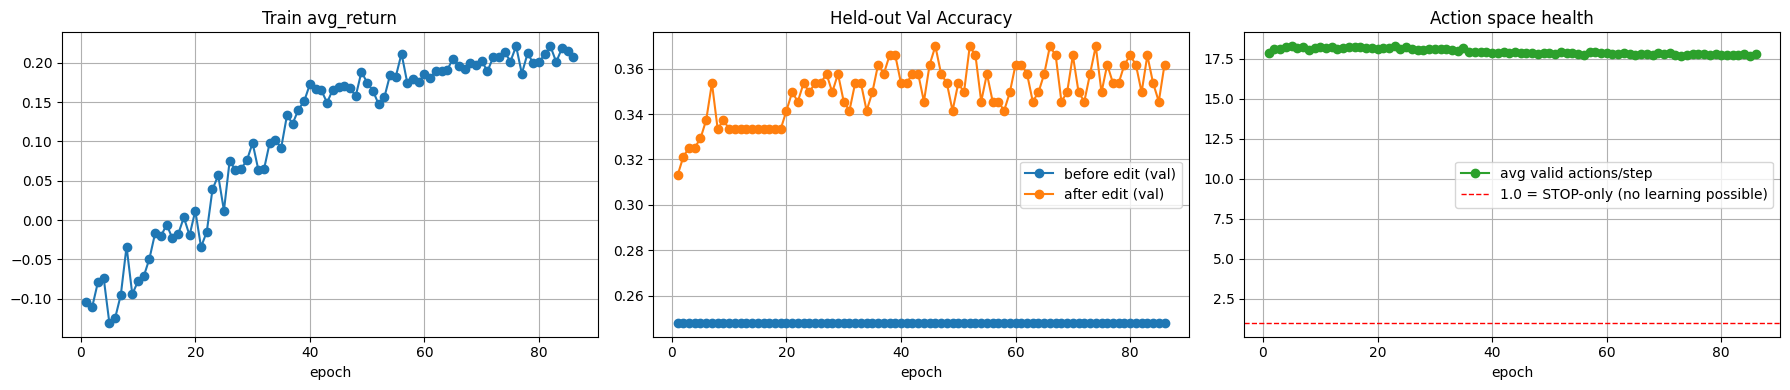

best 체크포인트 로드 (epoch 46, metric=0.3699)
[held-out val] 편집 전 정답률: 0.2480  ->  편집 후: 0.3699
[전체 헷갈리던 샘플(학습+검증 합)] 편집 전 정답률: 0.2404  ->  편집 후: 0.4088

[탐색 4클래스 val 전체 2801개] 원본 모델만: 0.5555  ->  정책 적용(안헷갈리면 그대로+헷갈리면 편집): 0.6541


In [13]:
# ============================================================
# RL 입력-편집 에이전트 (메인 모델 학습 없이, 이미 학습된 체크포인트만 사용)
# ============================================================
CFG = dict(
    purity_threshold=0.9,
    time_budget_hours=5.0,
    k_per_bucket=20, 
    vec_batch_size=256,
    min_epochs=10,
    patience_epochs=40,
)

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer

import config as C
from train import _force_eager_attention
from common import serialize, serialize_config_from, get_history_pairs
from exemplar_bank import EXPLORE_CLASSES, extract_pooled_embeddings, build_exemplar_bank, save_bank
from rl_edit import train_policy_vectorized, evaluate_policy_vectorized

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = C.TRAIN.output_dir  # "model" (recover 셀에서 /kaggle/working/model 로 복사해둔 것)


# ---- 학습 끝난 체크포인트 로드 ----
def load_trained_model(model_dir, device):
    """학습 때와 동일한 방식으로 인코더를 구성한다: 로컬에 저장해둔 t5gemma_base를
    T5Gemma2Encoder.from_pretrained(로컬경로)로 단독 재구성하지 않고, 학습 코드
    (T5GemmaEncoderClassifier.__init__)와 완전히 같은 경로 —
    AutoModel.from_pretrained(HF원본).encoder — 로 다시 만든다.
    (로컬 단독 재구성 경로가 학습 시점 구성과 미묘하게 달라 예측이 완전히
    깨지는 문제가 있어서, 아예 그 경로 자체를 없앴다.)"""
    from transformers import AutoModel

    meta = json.load(open(f"{model_dir}/backbone_meta.json"))
    label_maps = json.load(open(f"{model_dir}/label_maps.json"))

    full = AutoModel.from_pretrained(meta.get("model_name", C.MODEL_NAME), dtype=torch.bfloat16)
    base_encoder = full.encoder
    if hasattr(base_encoder, "vision_tower"):
        del base_encoder.vision_tower
    if hasattr(base_encoder, "multi_modal_projector"):
        del base_encoder.multi_modal_projector
    del full
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    _force_eager_attention(base_encoder)

    if meta.get("use_lora"):
        from peft import PeftModel
        encoder = PeftModel.from_pretrained(base_encoder, f"{model_dir}/lora_weights")
        encoder = encoder.merge_and_unload()
    else:
        encoder = base_encoder
    encoder.to(device).eval()
    for p in encoder.parameters():
        p.requires_grad = False   # 메인 모델 완전 고정

    h = base_encoder.embed_tokens.weight.shape[-1]
    n_classes = len(label_maps["id2label"])
    heads = torch.load(f"{model_dir}/heads.pt", map_location=device)
    attn = nn.Linear(h, 1).to(device); attn.load_state_dict(heads["attn"])
    classifier = nn.Linear(h, n_classes).to(device); classifier.load_state_dict(heads["classifier"])
    for p in list(attn.parameters()) + list(classifier.parameters()):
        p.requires_grad = False

    class Loaded(nn.Module):
        def __init__(self):
            super().__init__()
    m = Loaded()
    m.encoder, m.attn, m.classifier = encoder, attn, classifier
    m.eval()
    return m, label_maps


# ---- 1) 모델 로드 ----
model, label_maps = load_trained_model(MODEL_DIR, DEVICE)
tok = AutoTokenizer.from_pretrained(MODEL_DIR)
id2label = {int(k): v for k, v in label_maps["id2label"].items()}
label2id = label_maps["label2id"]
print("PRODUCTION: 학습된 체크포인트 로드 완료. 클래스 수:", len(id2label))


# ---- 2) val DataFrame 복원 (val_probs.npz의 id 순서 기준) ----
df_merged = pd.read_json("/kaggle/working/train_merged.jsonl", lines=True)
df_merged["id"] = df_merged["id"].astype(str)

val_npz = np.load(f"{MODEL_DIR}/val_probs.npz", allow_pickle=True)
val_ids = val_npz["ids"].astype(str)
df_val = df_merged.set_index("id").loc[val_ids].reset_index()
# 학습 당시 실제로 쓰인 직렬화 설정을 그대로 로드 (지금 config.py의 C.SER이 아니라
# 반드시 이 파일을 신뢰의 근원으로 삼는다)
ser_cfg = json.load(open(f"{MODEL_DIR}/serialize_config.json"))
print("val 샘플 수:", len(df_val))


# ---- 2-1) 재로드 검증: 학습 당시 저장된 예측 vs 지금 재계산한 예측이 일치하는지 확인 ----
@torch.no_grad()
def predict_probs(texts, batch_size=32):
    outs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, truncation=True, max_length=C.MAX_LENGTH,
                  padding=True, return_tensors="pt").to(DEVICE)
        out = model.encoder(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        H = out.last_hidden_state.float()
        scores = model.attn(H).squeeze(-1).masked_fill(enc["attention_mask"] == 0, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (H * w).sum(dim=1)
        logits = model.classifier(pooled)
        outs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.concatenate(outs, axis=0)


saved_probs_all = val_npz["probs"]
saved_classes = val_npz["classes"]
saved_pred_names = saved_classes[saved_probs_all.argmax(axis=1)]

check_texts = [serialize(r["current_prompt"], r["history"], r["session_meta"], ser_cfg)
              for _, r in df_val.iterrows()]
recomputed_probs = predict_probs(check_texts)
recomputed_pred_names = np.array([id2label[i] for i in recomputed_probs.argmax(axis=1)])

match_rate = (recomputed_pred_names == saved_pred_names).mean()
recomputed_acc = (recomputed_pred_names == df_val["action"].values).mean()
saved_acc = (saved_pred_names == df_val["action"].values).mean()
print(f"[재로드 검증] 학습 당시 저장된 예측 vs 지금 재계산한 예측 일치율: {match_rate:.4f} (1.0에 가까워야 정상)")
print(f"[재로드 검증] 학습 당시 val 정답률(저장값): {saved_acc:.4f}  /  지금 재계산한 val 정답률: {recomputed_acc:.4f}")
if match_rate < 0.9:
    print("  🚨 재로드 버그입니다. 아래 결과는 신뢰하지 말고 이 출력을 그대로 보여주세요.")


# ---- 3) 탐색 4클래스만 필터 + pooled 임베딩 추출 ----
df_explore = df_val[df_val["action"].isin(EXPLORE_CLASSES)].reset_index(drop=True)
texts_explore = [serialize(r["current_prompt"], r["history"], r["session_meta"], ser_cfg)
                 for _, r in df_explore.iterrows()]
embeddings = extract_pooled_embeddings(model, tok, texts_explore, DEVICE)
print("탐색 4클래스 샘플:", len(df_explore), "/ 임베딩 shape:", embeddings.shape)


# ---- 4) exemplar bank 구축 (kNN purity, 2D t-SNE 아님) ----
bank = build_exemplar_bank(df_explore, embeddings, purity_threshold=CFG["purity_threshold"], k_per_bucket=8)
save_bank(bank, "/kaggle/working/exemplar_bank.json")


# ---- 5) 헷갈리는 샘플만 필터링 (gold=4클래스 중 하나 AND 오답이거나 margin<0.2) ----
probs_explore = predict_probs(texts_explore)
pred_names_explore = np.array([id2label[i] for i in probs_explore.argmax(axis=1)])
pred_dist = pd.Series(pred_names_explore).value_counts(normalize=True)
print("[예측 분포 진단] 탐색 4클래스 샘플에 대한 예측 클래스 분포 (상위 5개):")
print(pred_dist.head(5))
if pred_dist.iloc[0] > 0.7:
    print(f"  🚨 예측의 {pred_dist.iloc[0]:.1%}가 '{pred_dist.index[0]}' 한 클래스로 쏠렸습니다. "
         "재로드 버그일 가능성이 높습니다.")

explore_ids = [label2id[c] for c in EXPLORE_CLASSES]
gold_ids = df_explore["action"].map(label2id).values
pred_ids = probs_explore.argmax(axis=1)
sub = probs_explore[:, explore_ids]
top2 = np.sort(sub, axis=1)[:, ::-1][:, :2]
margin = top2[:, 0] - top2[:, 1]
confused_mask = (pred_ids != gold_ids) | (margin < 0.2)
df_confusing = df_explore[confused_mask].reset_index(drop=True)
print(f"헷갈리는 샘플: {confused_mask.sum()} / {len(df_explore)} "
      f"(원래 정답률 {(pred_ids==gold_ids).mean():.4f})")

# exemplar bank가 헷갈리는 샘플들의 (클래스, history 길이) 조합을 얼마나 커버하는지 진단.
from collections import Counter
needed = Counter()
for _, r in df_confusing.iterrows():
    L = len(get_history_pairs(r["history"], C.SER.max_history_steps))
    needed[(r["action"], L)] += 1
covered = sum(n for (cls, L), n in needed.items() if bank.get(cls, {}).get(str(L)))
total = sum(needed.values())
print(f"[bank coverage] 헷갈리는 샘플 기준 (클래스,L) 조합 커버리지: "
      f"{covered}/{total} ({covered/total:.1%} 이 편집 가능한 버킷을 가짐)"
      if total else "[bank coverage] 헷갈리는 샘플 없음")


# ---- 6) 헷갈리는 샘플을 학습/검증(held-out)으로 분리 ----
from sklearn.model_selection import train_test_split

if len(df_confusing) >= 20:
    try:
        train_confusing, val_confusing = train_test_split(
            df_confusing, test_size=0.15, random_state=42, stratify=df_confusing["action"],
        )
    except ValueError:
        train_confusing, val_confusing = train_test_split(
            df_confusing, test_size=0.15, random_state=42,
        )
    train_confusing = train_confusing.reset_index(drop=True)
    val_confusing = val_confusing.reset_index(drop=True)
else:
    train_confusing, val_confusing = df_confusing, None
print(f"정책망 학습용: {len(train_confusing)}개 / 검증용(held-out): "
      f"{0 if val_confusing is None else len(val_confusing)}개")


# ---- 7) 정책망 학습 (REINFORCE + baseline, 메인 모델 고정, 벡터화 배치 실행) ----
CKPT_DIR = "/kaggle/working/policy_ckpt"
policy, hist = train_policy_vectorized(
    model, tok, bank, train_confusing, DEVICE,
    val_confusing=val_confusing,
    time_budget_hours=CFG["time_budget_hours"], vec_batch_size=CFG["vec_batch_size"], lr=3e-4,
    k_per_bucket=8, confuse_margin=0.2, step_penalty=0.05,
    patience_epochs=CFG["patience_epochs"], min_epochs=CFG["min_epochs"], batch_forward_size=256,
    ckpt_dir=CKPT_DIR, eval_every=1,
)
torch.save(policy.state_dict(), "/kaggle/working/edit_policy_final.pt")
print(f"체크포인트 저장 위치: {CKPT_DIR}/last.pt, {CKPT_DIR}/best.pt, {CKPT_DIR}/history.json")


# ---- 8) 학습 곡선 시각화 ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist["epoch"], hist["avg_return"], marker="o")
axes[0].set_title("Train avg_return"); axes[0].set_xlabel("epoch"); axes[0].grid(True)

val_epochs = [e for e, v in zip(hist["epoch"], hist["val_acc_after"]) if v is not None]
vb = [v for v in hist["val_acc_before"] if v is not None]
va = [v for v in hist["val_acc_after"] if v is not None]
if val_epochs:
    axes[1].plot(val_epochs, vb, marker="o", label="before edit (val)")
    axes[1].plot(val_epochs, va, marker="o", label="after edit (val)")
    axes[1].set_title("Held-out Val Accuracy")
    axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True)
else:
    axes[1].set_title("No validation set (too few samples)")

axes[2].plot(hist["epoch"], hist["avg_valid_actions"], marker="o", color="tab:green",
            label="avg valid actions/step")
axes[2].axhline(1.0, color="red", linestyle="--", linewidth=1,
                label="1.0 = STOP-only (no learning possible)")
axes[2].set_title("Action space health"); axes[2].set_xlabel("epoch")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/policy_learning_curve.png", dpi=150)
plt.show()


# ---- 9) best 체크포인트로 최종 평가 ----
best_ckpt_path = f"{CKPT_DIR}/best.pt"
try:
    best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
    policy.load_state_dict(best_ckpt["policy"])
    print(f"best 체크포인트 로드 (epoch {best_ckpt['epoch']}, metric={best_ckpt['metric']:.4f})")
except FileNotFoundError:
    print("best.pt 없음 -> 마지막 정책 그대로 평가")

if val_confusing is not None and len(val_confusing) > 0:
    vb_acc, va_acc = evaluate_policy_vectorized(
        policy, model, tok, bank, val_confusing, DEVICE,
        k_per_bucket=8, confuse_margin=0.2,
        vec_batch_size=CFG["vec_batch_size"], batch_forward_size=256,
    )
    print(f"[held-out val] 편집 전 정답률: {vb_acc:.4f}  ->  편집 후: {va_acc:.4f}")

acc_before, acc_after = evaluate_policy_vectorized(
    policy, model, tok, bank, df_confusing, DEVICE,
    k_per_bucket=8, confuse_margin=0.2, vec_batch_size=CFG["vec_batch_size"], batch_forward_size=256,
)
print(f"[전체 헷갈리던 샘플(학습+검증 합)] 편집 전 정답률: {acc_before:.4f}  ->  편집 후: {acc_after:.4f}")

overall_before, overall_after = evaluate_policy_vectorized(
    policy, model, tok, bank, df_explore, DEVICE,
    k_per_bucket=8, confuse_margin=0.2, vec_batch_size=CFG["vec_batch_size"], batch_forward_size=256,
)
print(f"\n[탐색 4클래스 val 전체 {len(df_explore)}개] "
      f"원본 모델만: {overall_before:.4f}  ->  정책 적용(안헷갈리면 그대로+헷갈리면 편집): {overall_after:.4f}")


In [14]:
# ---- 10) 메인 모델이 원래 검증했던 것과 완전히 같은 val set(14클래스 전체)에서
#          "원본 모델" vs "RL 정책 적용(탐색4클래스만 편집, 나머지 10개 클래스는 원본 그대로)" 비교
# ----------------------------------------------------------------------------
# 탐색 4클래스가 아닌 나머지 10개 클래스는 정책이 아예 손대지 않으므로, section 2-1에서
# 이미 계산해둔 recomputed_pred_names(원본, 편집 전)를 그대로 쓴다.
non_explore_mask = ~df_val["action"].isin(EXPLORE_CLASSES).values
non_explore_correct = int((recomputed_pred_names[non_explore_mask]
                          == df_val.loc[non_explore_mask, "action"].values).sum())
n_non_explore = int(non_explore_mask.sum())

explore_correct_before = int(round(overall_before * len(df_explore)))
explore_correct_after = int(round(overall_after * len(df_explore)))

full_acc_before = (non_explore_correct + explore_correct_before) / len(df_val)
full_acc_after = (non_explore_correct + explore_correct_after) / len(df_val)

print(f"\n[메인 모델 검증과 동일한 전체 val set, {len(df_val)}개 / 14클래스 전체]")
print(f"  탐색 4클래스 아닌 {n_non_explore}개는 정책 미적용(원본 그대로, 정답 {non_explore_correct}개)")
print(f"  원본 모델만 (RL 없음):                 {full_acc_before:.4f}  "
      f"(section 2-1의 재계산 정답률 {recomputed_acc:.4f}와 같아야 정상 — 교차검증)")
print(f"  RL 정책 적용(탐색4클래스만 편집):        {full_acc_after:.4f}")
print(f"  변화량: {full_acc_after - full_acc_before:+.4f}")


[메인 모델 검증과 동일한 전체 val set, 7062개 / 14클래스 전체]
  탐색 4클래스 아닌 4261개는 정책 미적용(원본 그대로, 정답 3424개)
  원본 모델만 (RL 없음):                 0.7052  (section 2-1의 재계산 정답률 0.7052와 같아야 정상 — 교차검증)
  RL 정책 적용(탐색4클래스만 편집):        0.7443
  변화량: +0.0391
